In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [4]:
main_path = '/Users/danny/Data_Analysis_Projects/PrescientAI_DS/data/'


# File paths
dev_reported_path = "company_x_dev_reported_metrics.csv"
dev_modeled_path  = "company_x_dev_modeled_metrics.csv"
prod_reported_path = "company_x_prod_reported_metrics.csv"
prod_modeled_path  = "company_x_prod_modeled_metrics.csv"

# Load datasets
dev_reported = pd.read_csv(main_path + dev_reported_path, parse_dates=["REPORTED_DATE"])
dev_modeled  = pd.read_csv(main_path + dev_modeled_path, parse_dates=["REPORTED_DATE"])
prod_reported = pd.read_csv(main_path + prod_reported_path, parse_dates=["REPORTED_DATE"])
prod_modeled  = pd.read_csv(main_path + prod_modeled_path, parse_dates=["REPORTED_DATE"])

for df in [dev_reported, dev_modeled, prod_reported, prod_modeled]:
    df["COMPANY"] = df["COMPANY"].astype("category")
    df["MARKETING_CHANNEL"] = df["MARKETING_CHANNEL"].astype("category")
    df["METRIC_NAME"] = df["METRIC_NAME"].astype("category")

dev_reported.shape, dev_modeled.shape, prod_reported.shape, prod_modeled.shape

((28950, 6), (55844, 6), (28950, 6), (55214, 6))

dev_reported has 0 negative METRIC_VALUE entries (out of 28950)
prod_reported has 0 negative METRIC_VALUE entries (out of 28950)
dev_modeled has 0 negative METRIC_VALUE entries (out of 55844)
prod_modeled has 0 negative METRIC_VALUE entries (out of 55214)

dev_reported exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-nul

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


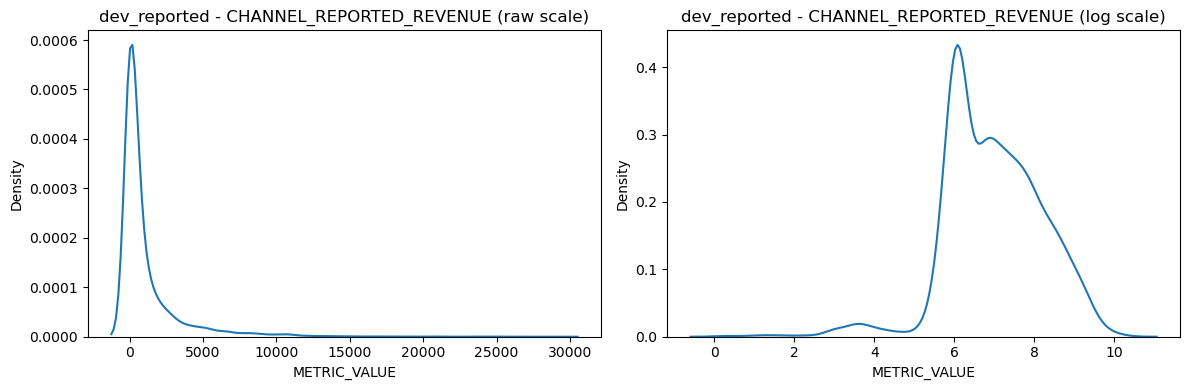

  CLICKS: 538 outliers (out of 4660)


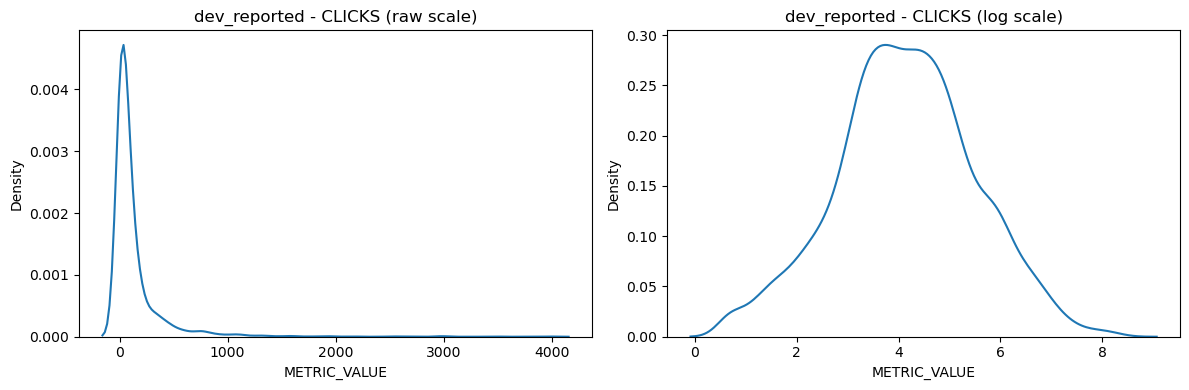

  CLICKTHROUGHS: 5 outliers (out of 154)


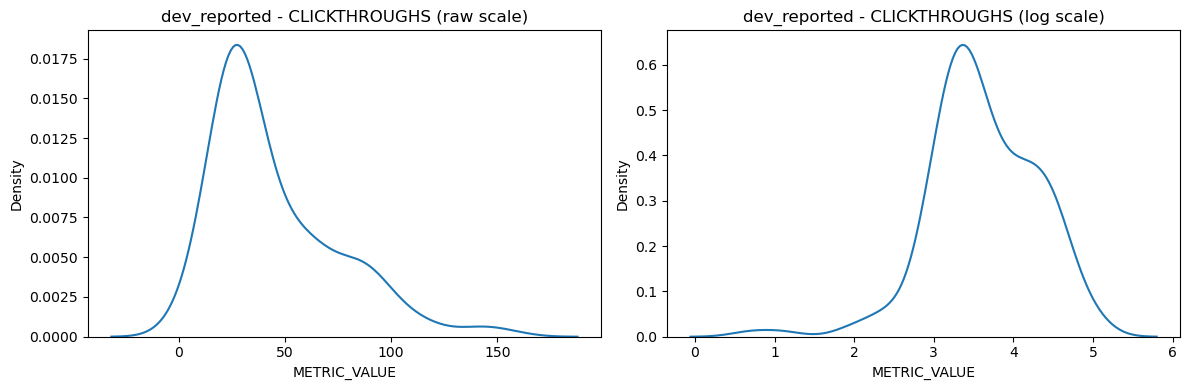

  CONVERSIONS: 596 outliers (out of 4337)


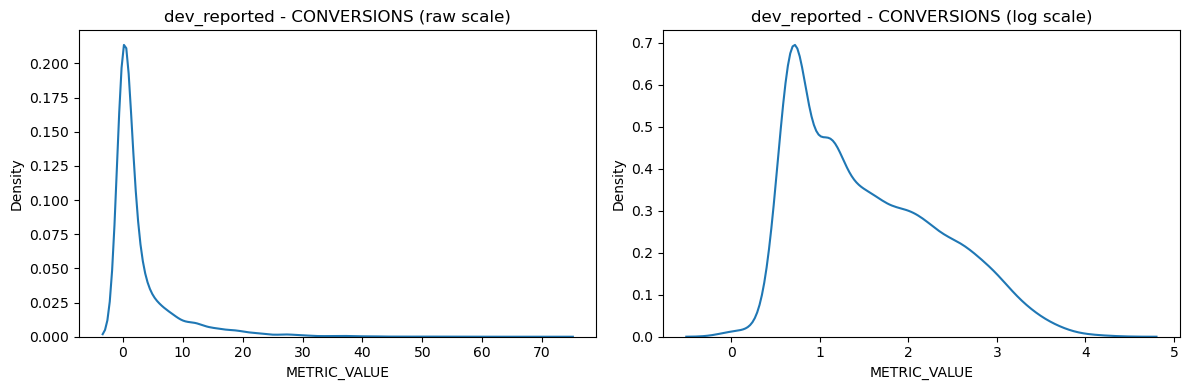

  CPC: 65 outliers (out of 883)


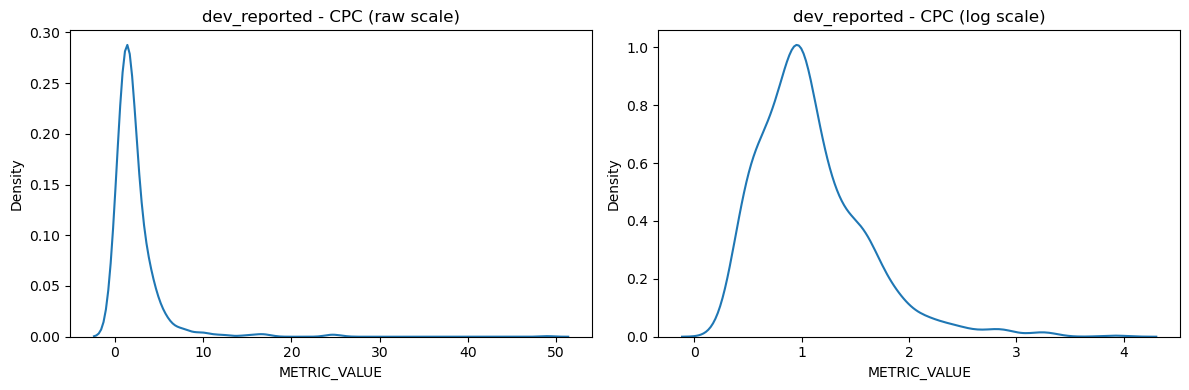

  CPM: 71 outliers (out of 744)


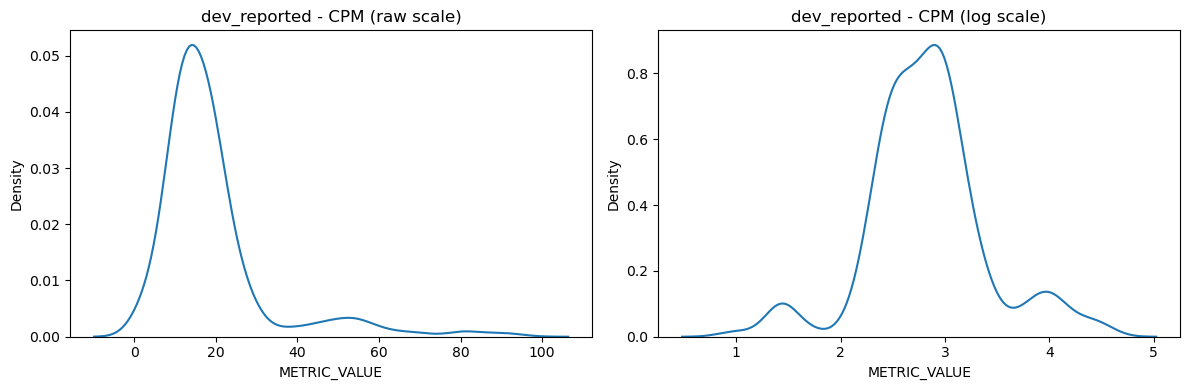

  CTR: 154 outliers (out of 1658)


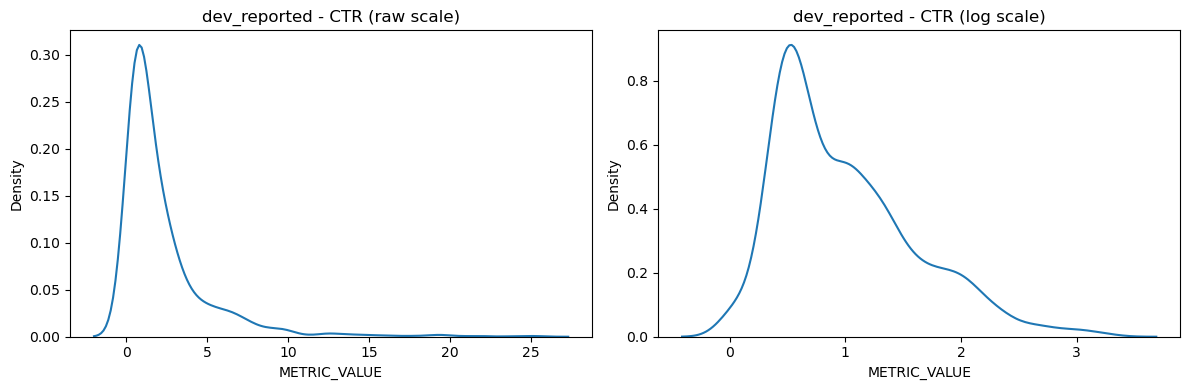

  CVR: 100 outliers (out of 914)


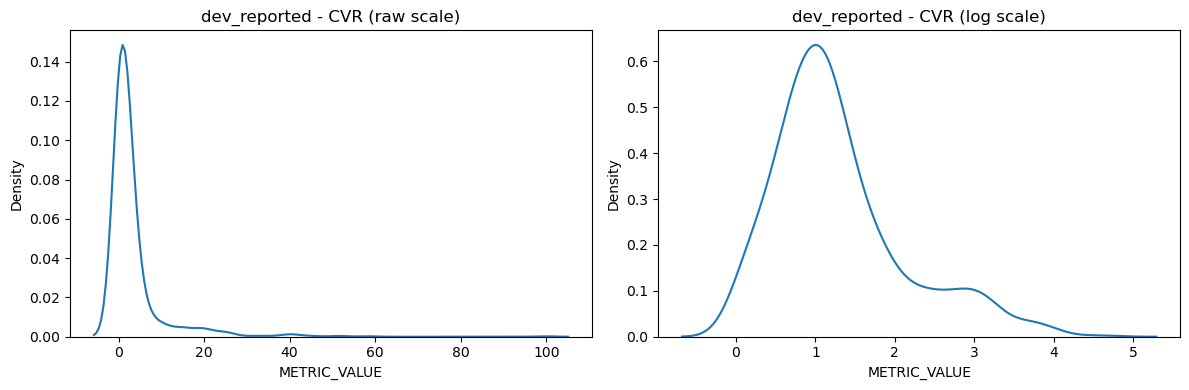

  FREQUENCY: 131 outliers (out of 765)


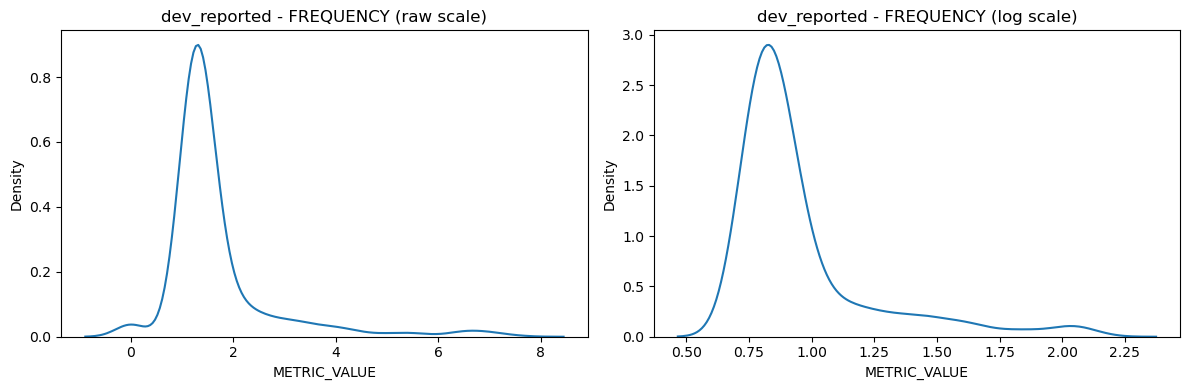

  IMPRESSIONS: 522 outliers (out of 4743)


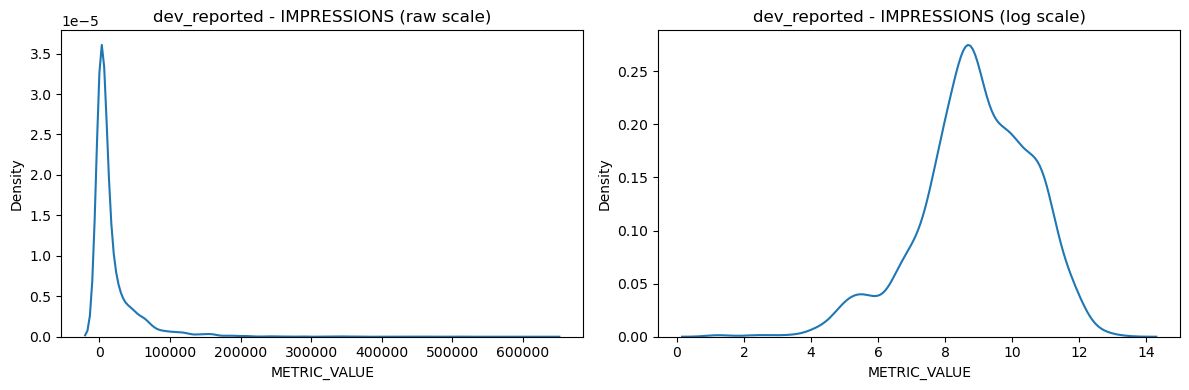

  REACH: 137 outliers (out of 905)


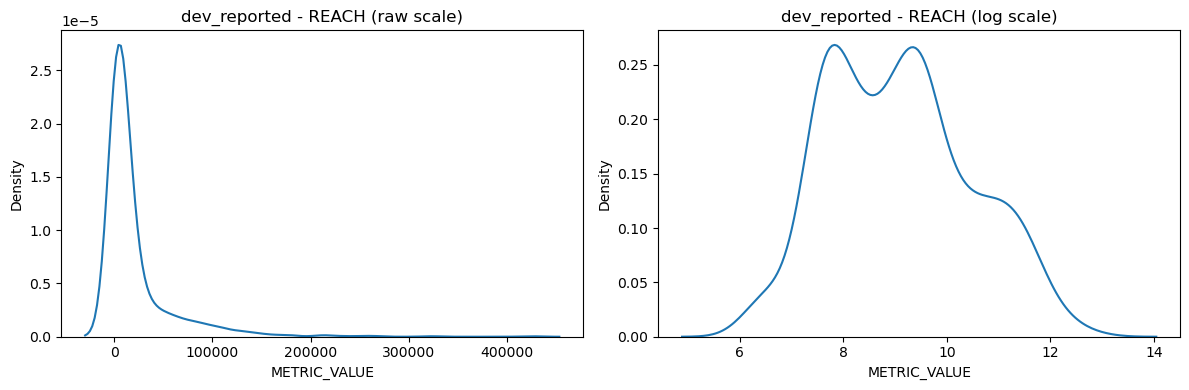

  SPEND: 532 outliers (out of 4743)


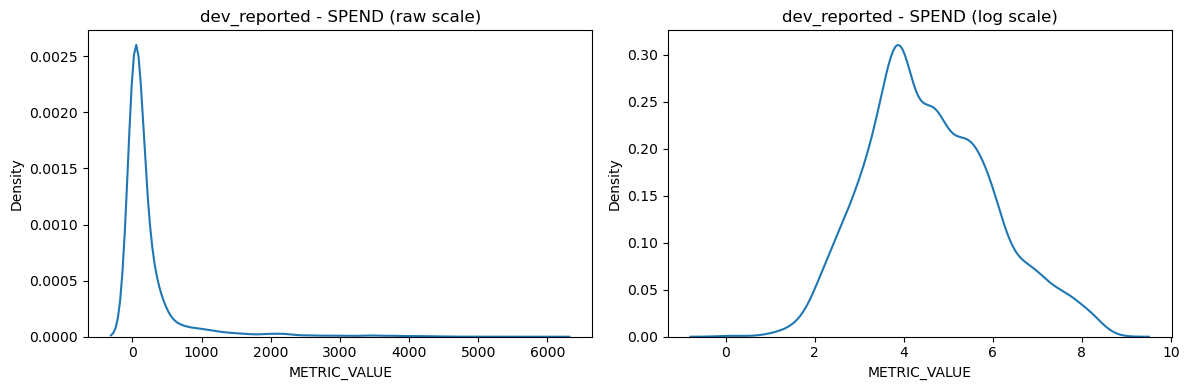


prod_reported exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 764.3 KB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL      CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X        STACKADAPT           430328   
1    2024-07-01  C

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


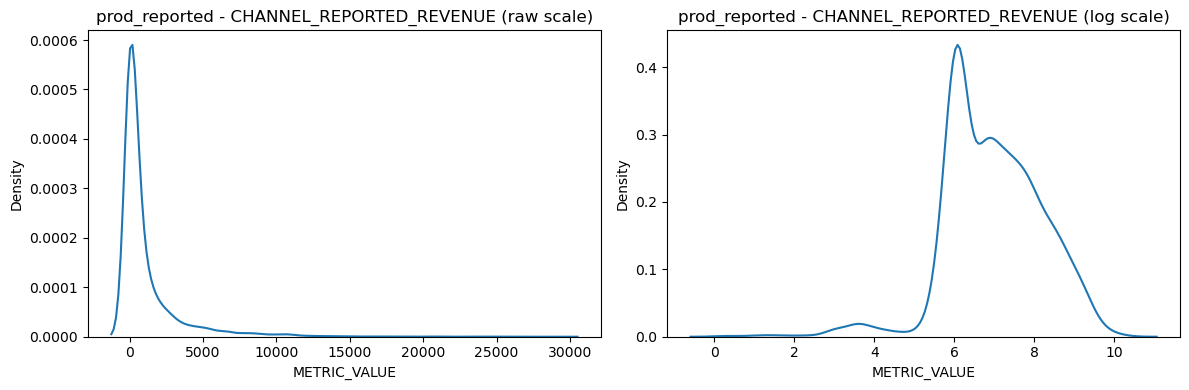

  CLICKS: 538 outliers (out of 4660)


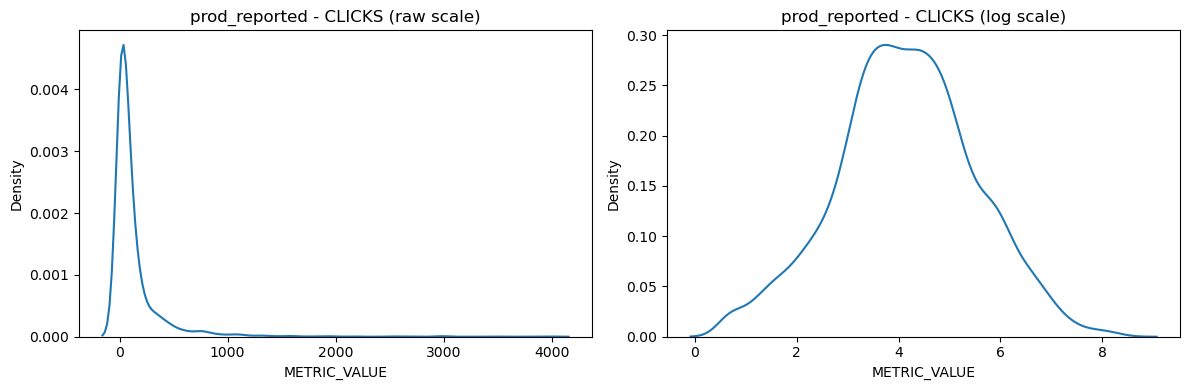

  CLICKTHROUGHS: 5 outliers (out of 154)


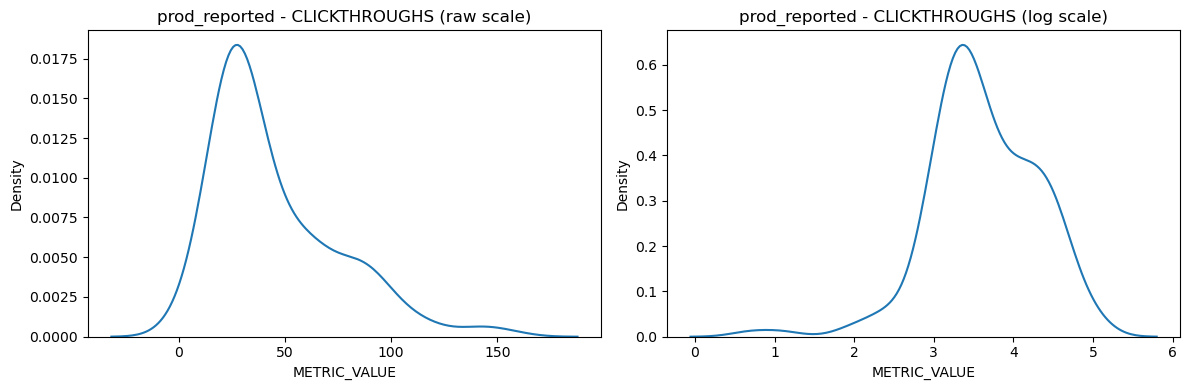

  CONVERSIONS: 596 outliers (out of 4337)


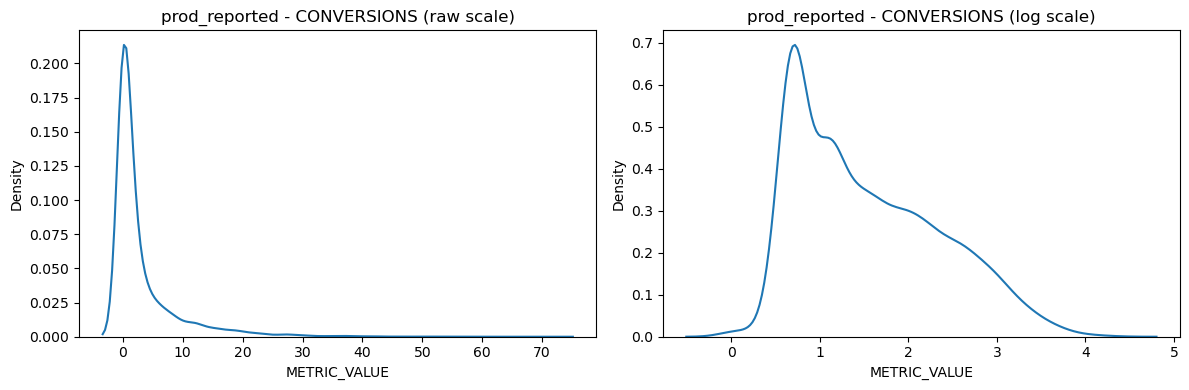

  CPC: 65 outliers (out of 883)


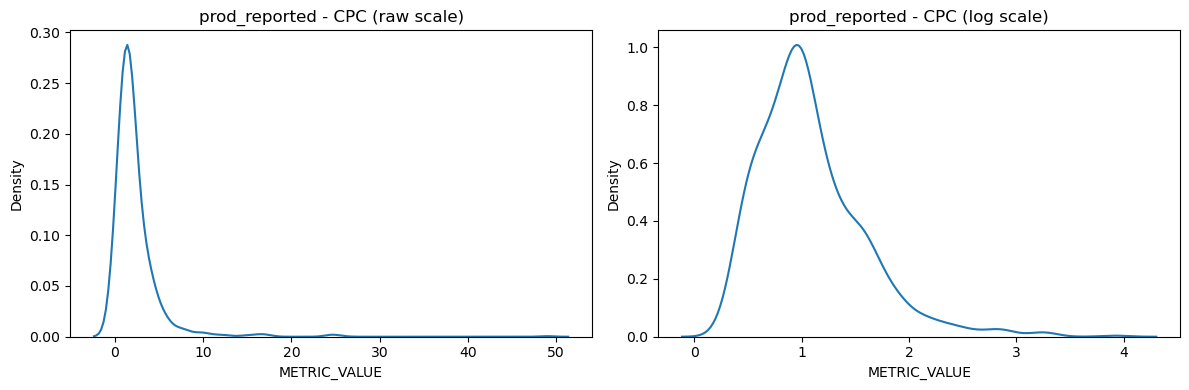

  CPM: 71 outliers (out of 744)


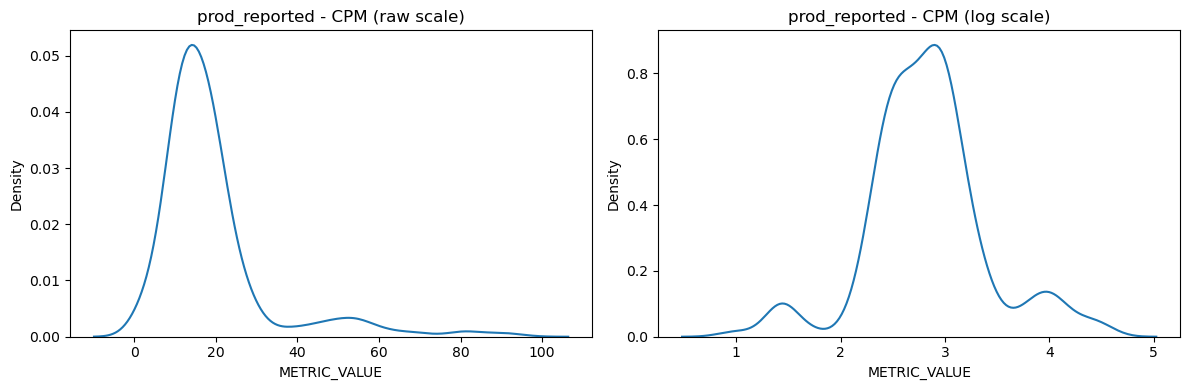

  CTR: 154 outliers (out of 1658)


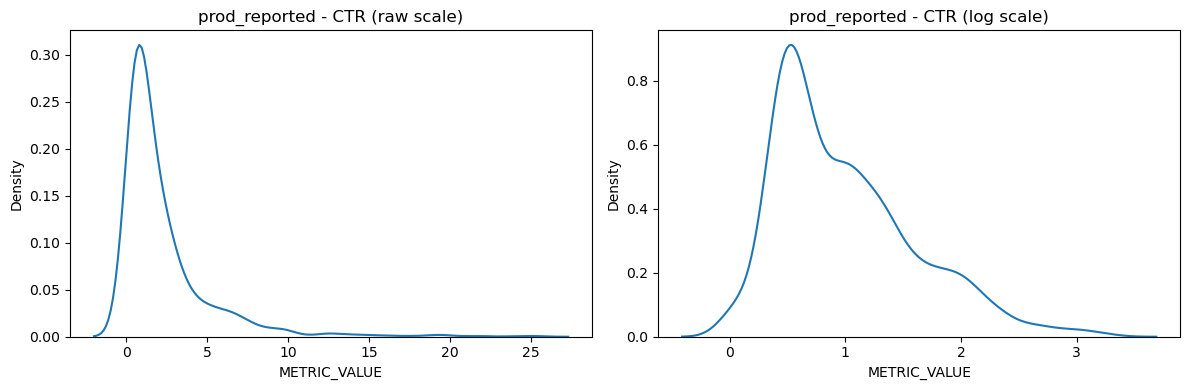

  CVR: 100 outliers (out of 914)


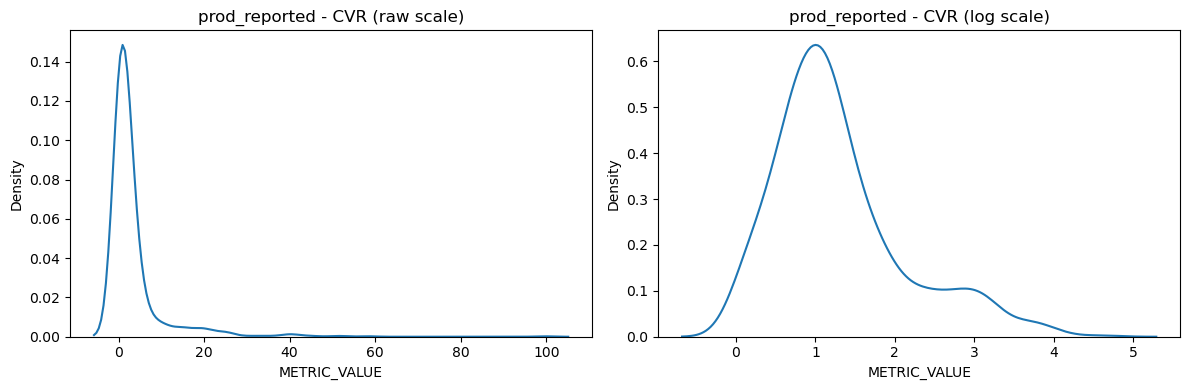

  FREQUENCY: 131 outliers (out of 765)


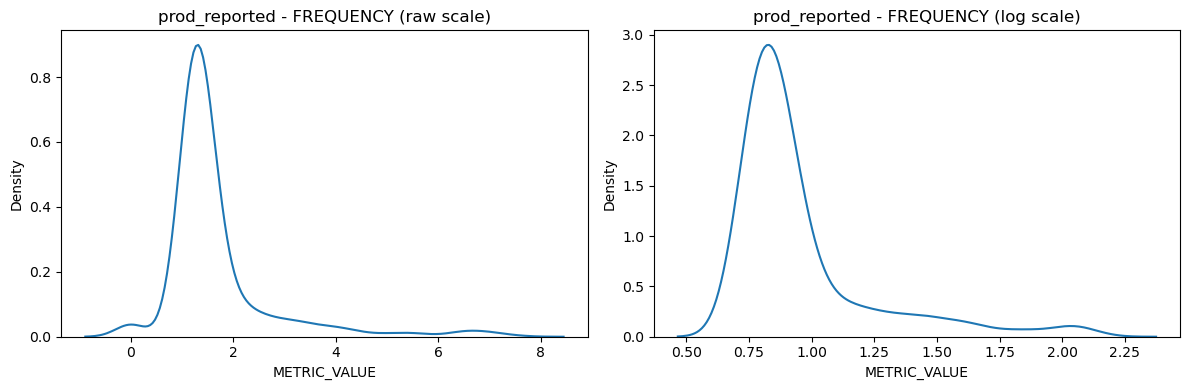

  IMPRESSIONS: 522 outliers (out of 4743)


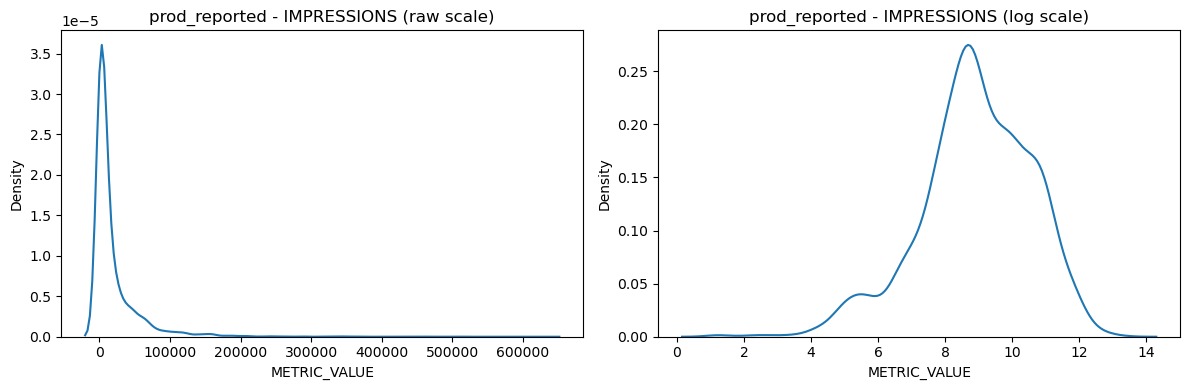

  REACH: 137 outliers (out of 905)


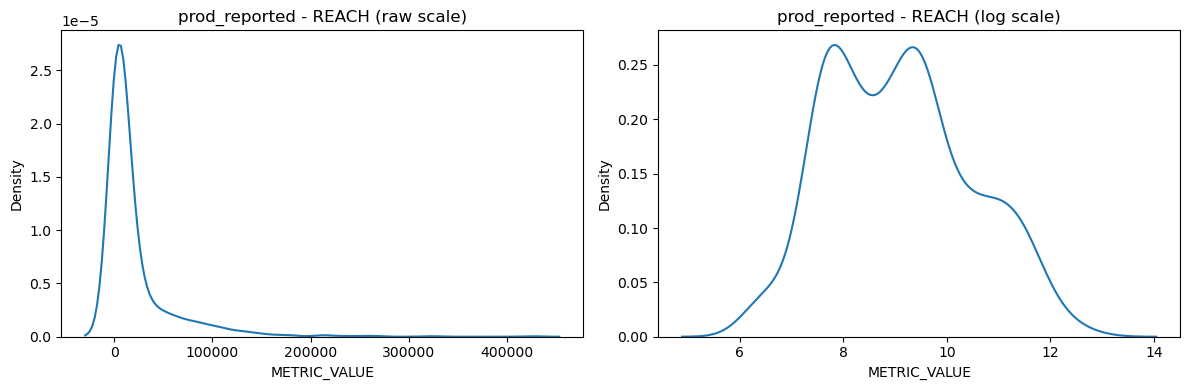

  SPEND: 532 outliers (out of 4743)


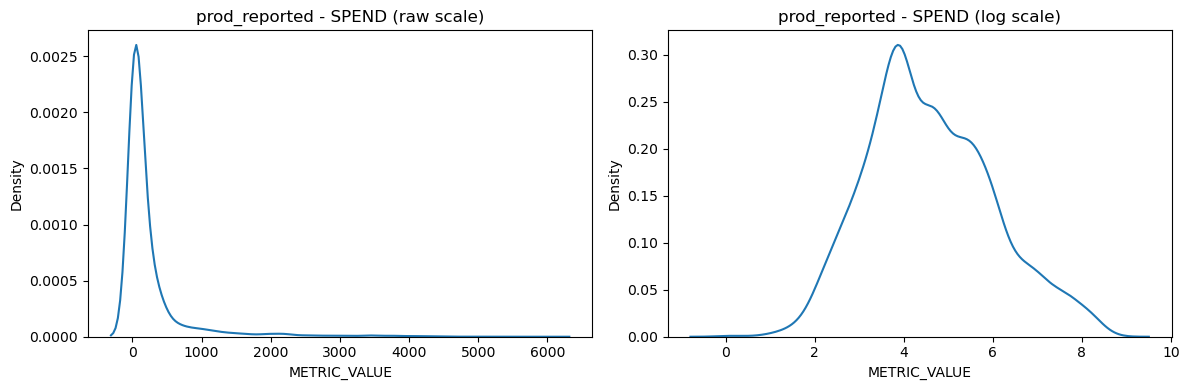


dev_modeled exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55844 entries, 0 to 55843
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      55844 non-null  datetime64[ns]
 1   COMPANY            55844 non-null  category      
 2   MARKETING_CHANNEL  55844 non-null  category      
 3   CAMPAIGN_ID        55844 non-null  int64         
 4   METRIC_NAME        55844 non-null  category      
 5   METRIC_VALUE       55844 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL       CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X        STACKADAPT            162460   
1    2024-07-01  COM

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


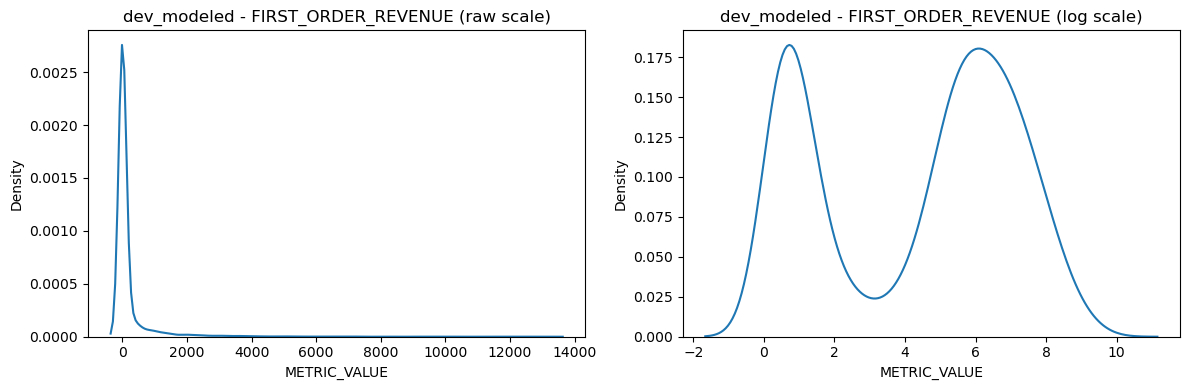

  SECOND_ORDER_REVENUE: 6962 outliers (out of 45025)


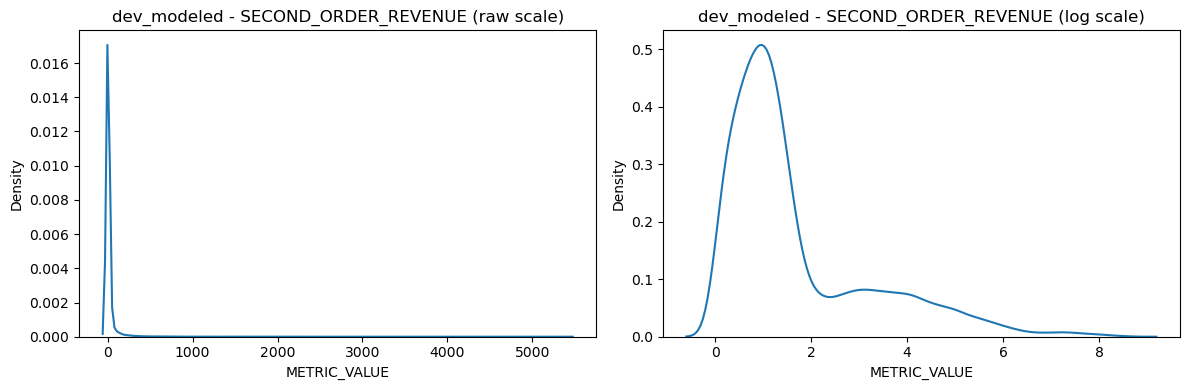


prod_modeled exploratory analysis:
Missing values per column:
REPORTED_DATE        0
COMPANY              0
MARKETING_CHANNEL    0
CAMPAIGN_ID          0
METRIC_NAME          0
METRIC_VALUE         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55214 entries, 0 to 55213
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      55214 non-null  datetime64[ns]
 1   COMPANY            55214 non-null  category      
 2   MARKETING_CHANNEL  55214 non-null  category      
 3   CAMPAIGN_ID        55214 non-null  int64         
 4   METRIC_NAME        55214 non-null  category      
 5   METRIC_VALUE       55214 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 1.4 MB
None
  REPORTED_DATE    COMPANY MARKETING_CHANNEL    CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281654088577   
1    2024-07-01  COMPANY_

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\316713930.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for metric, group in df.groupby("METRIC_NAME"):


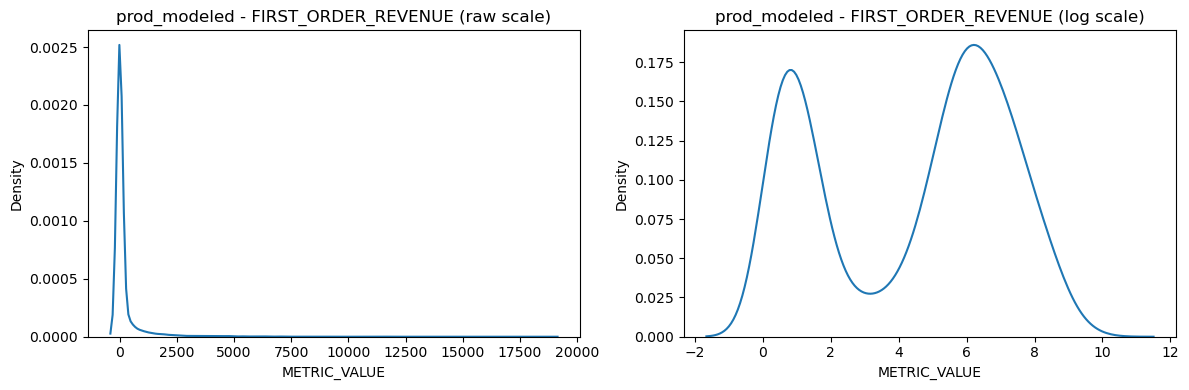

  SECOND_ORDER_REVENUE: 10060 outliers (out of 44395)


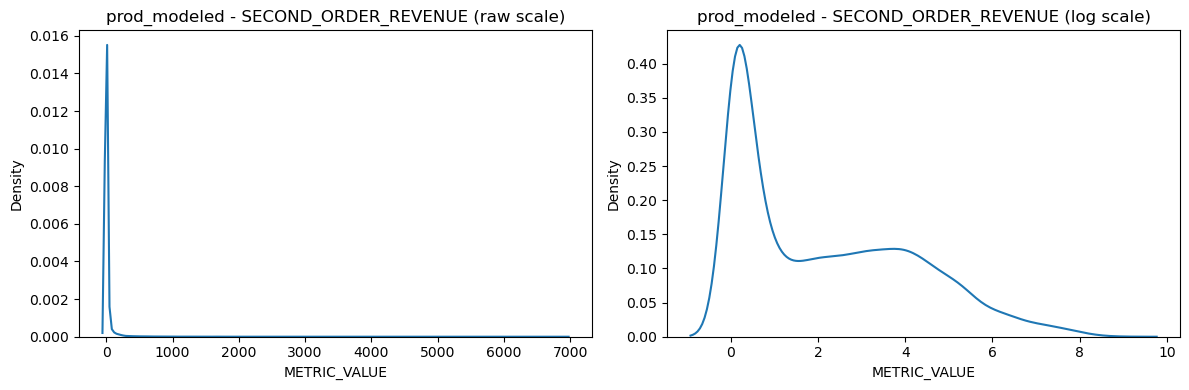

In [5]:
datasets = {
    "dev_reported": dev_reported,
    "prod_reported": prod_reported,
    "dev_modeled": dev_modeled,
    "prod_modeled": prod_modeled
}

for name, df in datasets.items():
    if "METRIC_VALUE" in df.columns:
        negative_count = (df["METRIC_VALUE"] < 0).sum()
        print(f"{name} has {negative_count} negative METRIC_VALUE entries (out of {len(df)})")

for name, df in datasets.items():
    print(f"\n{name} exploratory analysis:")

    # 1️⃣ Missing values
    print("Missing values per column:")
    print(df.isna().sum())

    # 2️⃣ Dataset info
    print(df.info())
    print(df.head())

    # 3️⃣ IQR outlier detection & density plots
    if "METRIC_NAME" in df.columns and "METRIC_VALUE" in df.columns:
        # Group by METRIC_NAME
        for metric, group in df.groupby("METRIC_NAME"):
            col = "METRIC_VALUE"
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = group[(group[col] < lower_bound) | (group[col] > upper_bound)]
            print(f"  {metric}: {len(outliers)} outliers (out of {len(group)})")

            # Plot raw vs log-transformed density
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.kdeplot(group[col].dropna(), ax=axes[0])
            axes[0].set_title(f"{name} - {metric} (raw scale)")

            if (group[col] > 0).any():
                sns.kdeplot(np.log1p(group[col][group[col] > 0]), ax=axes[1])
                axes[1].set_title(f"{name} - {metric} (log scale)")

            plt.tight_layout()
            plt.show()
    else:
        # If no METRIC_NAME column, just numeric columns excluding CAMPAIGN_ID
        numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c.upper() != "CAMPAIGN_ID"]
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            print(f"  {col}: {len(outliers)} outliers (out of {len(df)})")

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.kdeplot(df[col].dropna(), ax=axes[0])
            axes[0].set_title(f"{name} - {col} (raw scale)")

            if (df[col] > 0).any():
                sns.kdeplot(np.log1p(df[col][df[col] > 0]), ax=axes[1])
                axes[1].set_title(f"{name} - {col} (log scale)")

            plt.tight_layout()
            plt.show()

In [6]:
# 2️⃣ Quick info and basic stats
for df, name in zip([dev_reported, prod_reported, dev_modeled, prod_modeled],
                    ["dev_reported", "prod_reported", "dev_modeled", "prod_modeled"]):
    print(f"\n{name} info:")
    print(df.info())
    print(f"{name} head:")
    print(df.head())
    print(f"{name} description:")
    print(df.describe(include='all'))


dev_reported info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28950 entries, 0 to 28949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   REPORTED_DATE      28950 non-null  datetime64[ns]
 1   COMPANY            28950 non-null  category      
 2   MARKETING_CHANNEL  28950 non-null  category      
 3   CAMPAIGN_ID        28950 non-null  int64         
 4   METRIC_NAME        28950 non-null  category      
 5   METRIC_VALUE       28950 non-null  float64       
dtypes: category(3), datetime64[ns](1), float64(1), int64(1)
memory usage: 764.3 KB
None
dev_reported head:
  REPORTED_DATE    COMPANY MARKETING_CHANNEL    CAMPAIGN_ID  \
0    2024-07-01  COMPANY_X           ADWORDS    21167876130   
1    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281663656977   
2    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281654088577   
3    2024-07-01  COMPANY_X      FACEBOOK_ADS  6281663656977   
4    2024


dev_reported unique campaigns: 97
dev_reported unique channels: 8
dev_reported unique metric names: 12

prod_reported unique campaigns: 97
prod_reported unique channels: 8
prod_reported unique metric names: 12

dev_modeled unique campaigns: 172
dev_modeled unique channels: 8
dev_modeled unique metric names: 2

prod_modeled unique campaigns: 172
prod_modeled unique channels: 8
prod_modeled unique metric names: 2


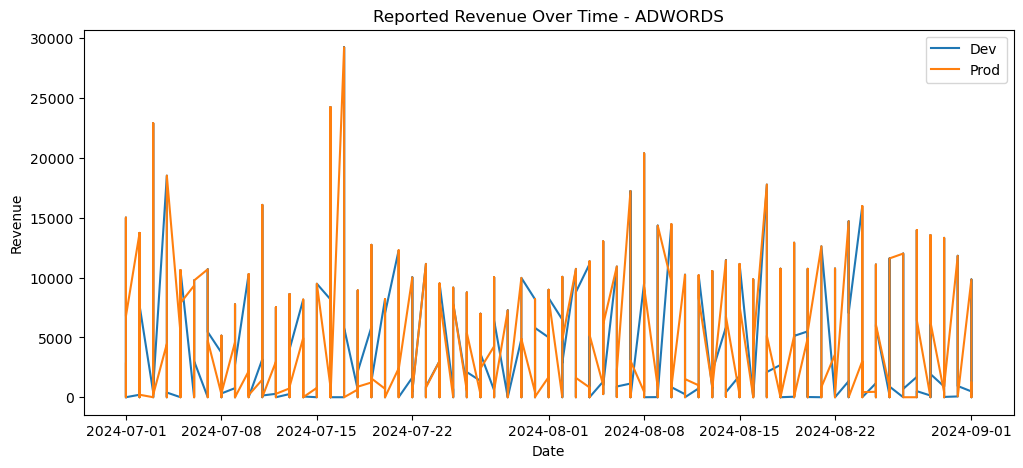

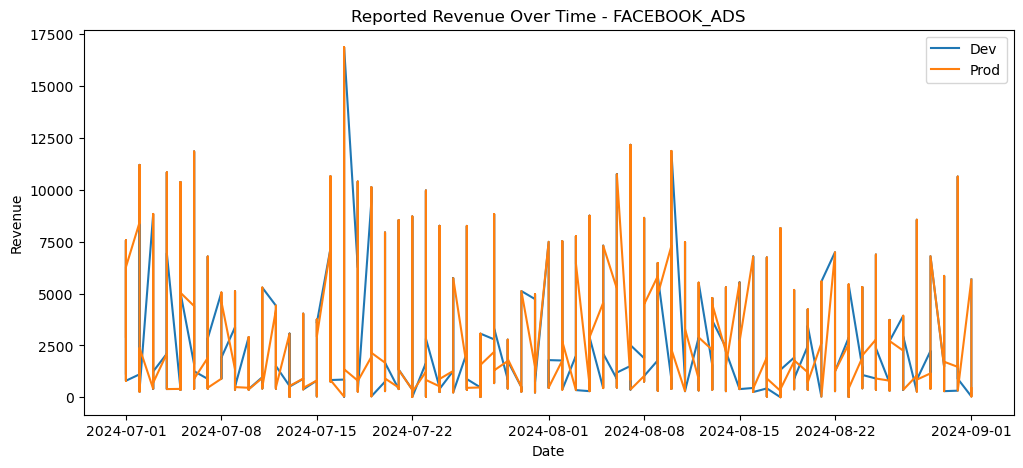

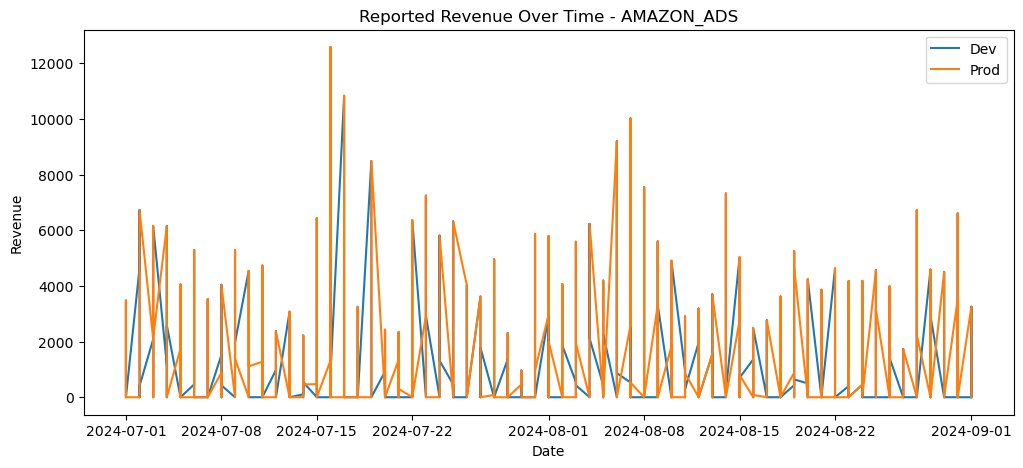

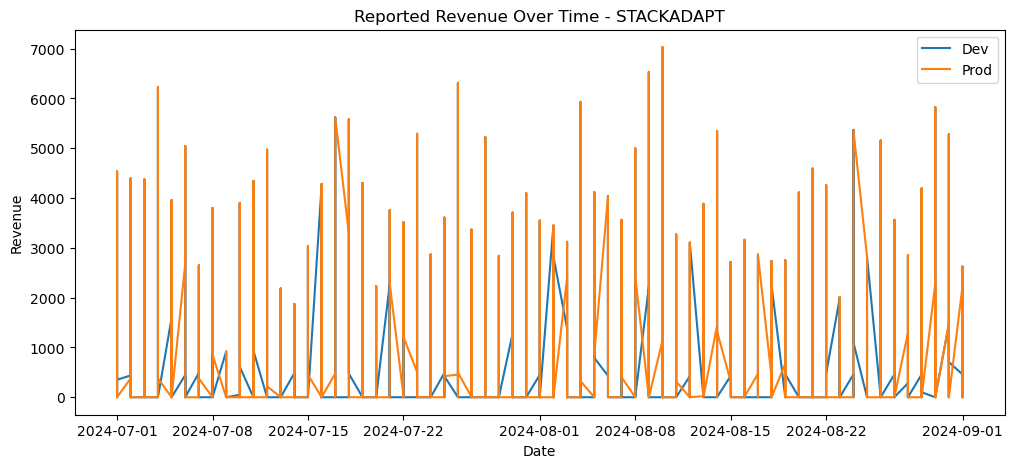

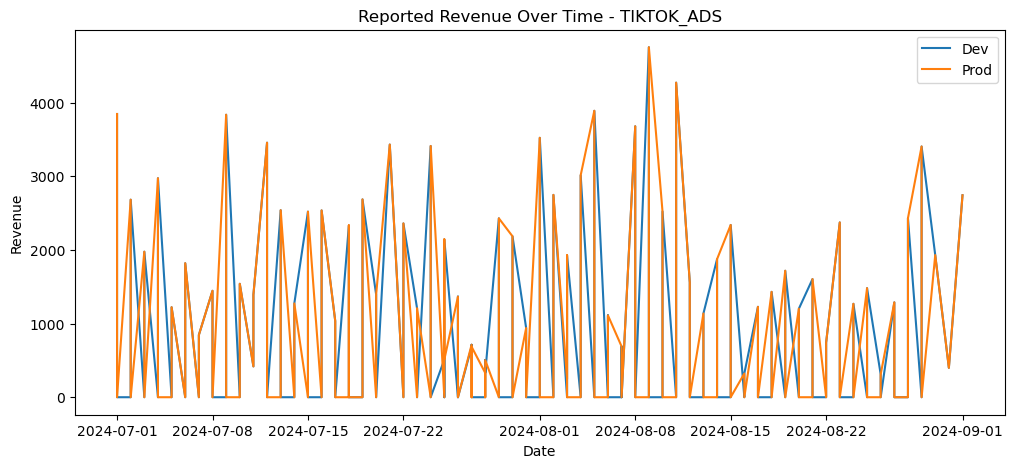

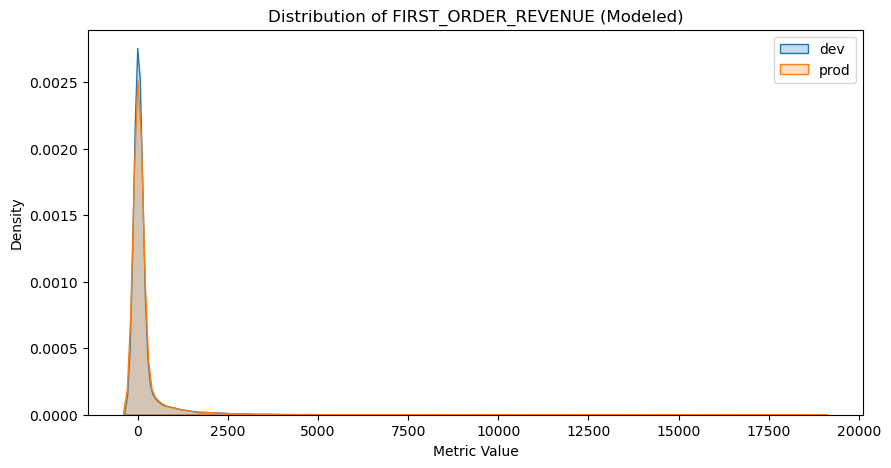

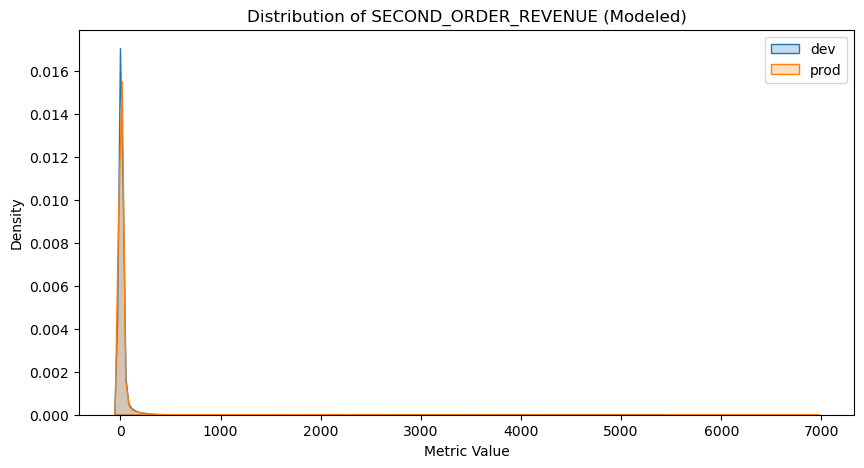

In [7]:
# 3️⃣ Unique campaigns & channels
for df, name in zip([dev_reported, prod_reported, dev_modeled, prod_modeled],
                    ["dev_reported", "prod_reported", "dev_modeled", "prod_modeled"]):
    print(f"\n{name} unique campaigns: {df['CAMPAIGN_ID'].nunique()}")
    print(f"{name} unique channels: {df['MARKETING_CHANNEL'].nunique()}")
    print(f"{name} unique metric names: {df['METRIC_NAME'].nunique()}")

# 5️⃣ Time series comparison per channel
channels = dev_reported['MARKETING_CHANNEL'].unique()[:5]  # first 5 channels for simplicity

for channel in channels:
    plt.figure(figsize=(12,5))
    for df, label in zip([dev_reported, prod_reported], ['Dev', 'Prod']):
        df_channel = df[(df['MARKETING_CHANNEL']==channel) & (df['METRIC_NAME']=='CHANNEL_REPORTED_REVENUE')]
        plt.plot(df_channel['REPORTED_DATE'], df_channel['METRIC_VALUE'], label=label)
    plt.title(f"Reported Revenue Over Time - {channel}")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.show()

# 6️⃣ Modeled revenue comparison
for metric in ['FIRST_ORDER_REVENUE', 'SECOND_ORDER_REVENUE']:
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=dev_modeled[dev_modeled['METRIC_NAME']==metric], x='METRIC_VALUE', label='dev', fill=True)
    sns.kdeplot(data=prod_modeled[prod_modeled['METRIC_NAME']==metric], x='METRIC_VALUE', label='prod', fill=True)
    plt.title(f'Distribution of {metric} (Modeled)')
    plt.xlabel('Metric Value')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [74]:
# Pivot reported datasets with CAMPAIGN_ID
reported_pivots = {}
for name, df in [("dev_reported", dev_reported), ("prod_reported", prod_reported)]:
    pivot = df.pivot_table(
        index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        columns="METRIC_NAME",
        values="METRIC_VALUE",
        aggfunc="sum"
    ).reset_index()
    reported_pivots[name] = pivot

# Pivot modeled datasets with CAMPAIGN_ID
modeled_pivots = {}
for name, df in [("dev_modeled", dev_modeled), ("prod_modeled", prod_modeled)]:
    pivot = df.pivot_table(
        index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        columns="METRIC_NAME",
        values="METRIC_VALUE",
        aggfunc="sum"
    ).reset_index()
    modeled_pivots[name] = pivot

# Compare revenue per campaign
for env in ["dev", "prod"]:
    reported = reported_pivots[f"{env}_reported"]
    modeled = modeled_pivots[f"{env}_modeled"].copy()

    # Compute total modeled revenue
    modeled["TOTAL_MODELED_REVENUE"] = (
        modeled.get("FIRST_ORDER_REVENUE", 0) + modeled.get("SECOND_ORDER_REVENUE", 0)
    )

    # Merge with CAMPAIGN_ID to avoid collapsing multiple campaigns
    comparison = reported.merge(
        modeled[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        how="inner"
    )

    # Calculate differences
    comparison["REVENUE_DIFF"] = comparison.get("CHANNEL_REPORTED_REVENUE", 0) - comparison["TOTAL_MODELED_REVENUE"]

    print(f"\n{env.upper()} Revenue Comparison (per campaign):")
    display(comparison.head())


C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4113744847.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4113744847.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(



DEV Revenue Comparison (per campaign):


C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4113744847.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4113744847.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


METRIC_NAME,REPORTED_DATE,MARKETING_CHANNEL,CAMPAIGN_ID,CHANNEL_REPORTED_REVENUE,CLICKS,CLICKTHROUGHS,CONVERSIONS,CPC,CPM,CTR,CVR,FREQUENCY,IMPRESSIONS,REACH,SPEND,TOTAL_MODELED_REVENUE,REVENUE_DIFF
0,2024-07-01,ADWORDS,430309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-01,ADWORDS,430311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-07-01,ADWORDS,430317,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-01,ADWORDS,430322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-01,ADWORDS,430324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



PROD Revenue Comparison (per campaign):


METRIC_NAME,REPORTED_DATE,MARKETING_CHANNEL,CAMPAIGN_ID,CHANNEL_REPORTED_REVENUE,CLICKS,CLICKTHROUGHS,CONVERSIONS,CPC,CPM,CTR,CVR,FREQUENCY,IMPRESSIONS,REACH,SPEND,TOTAL_MODELED_REVENUE,REVENUE_DIFF
0,2024-07-01,ADWORDS,430309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-01,ADWORDS,430311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-07-01,ADWORDS,430317,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-01,ADWORDS,430322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-01,ADWORDS,430324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


C:\Users\danny\AppData\Local\Temp\ipykernel_22844\42854344.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison.groupby(["REPORTED_DATE","MARKETING_CHANNEL"])


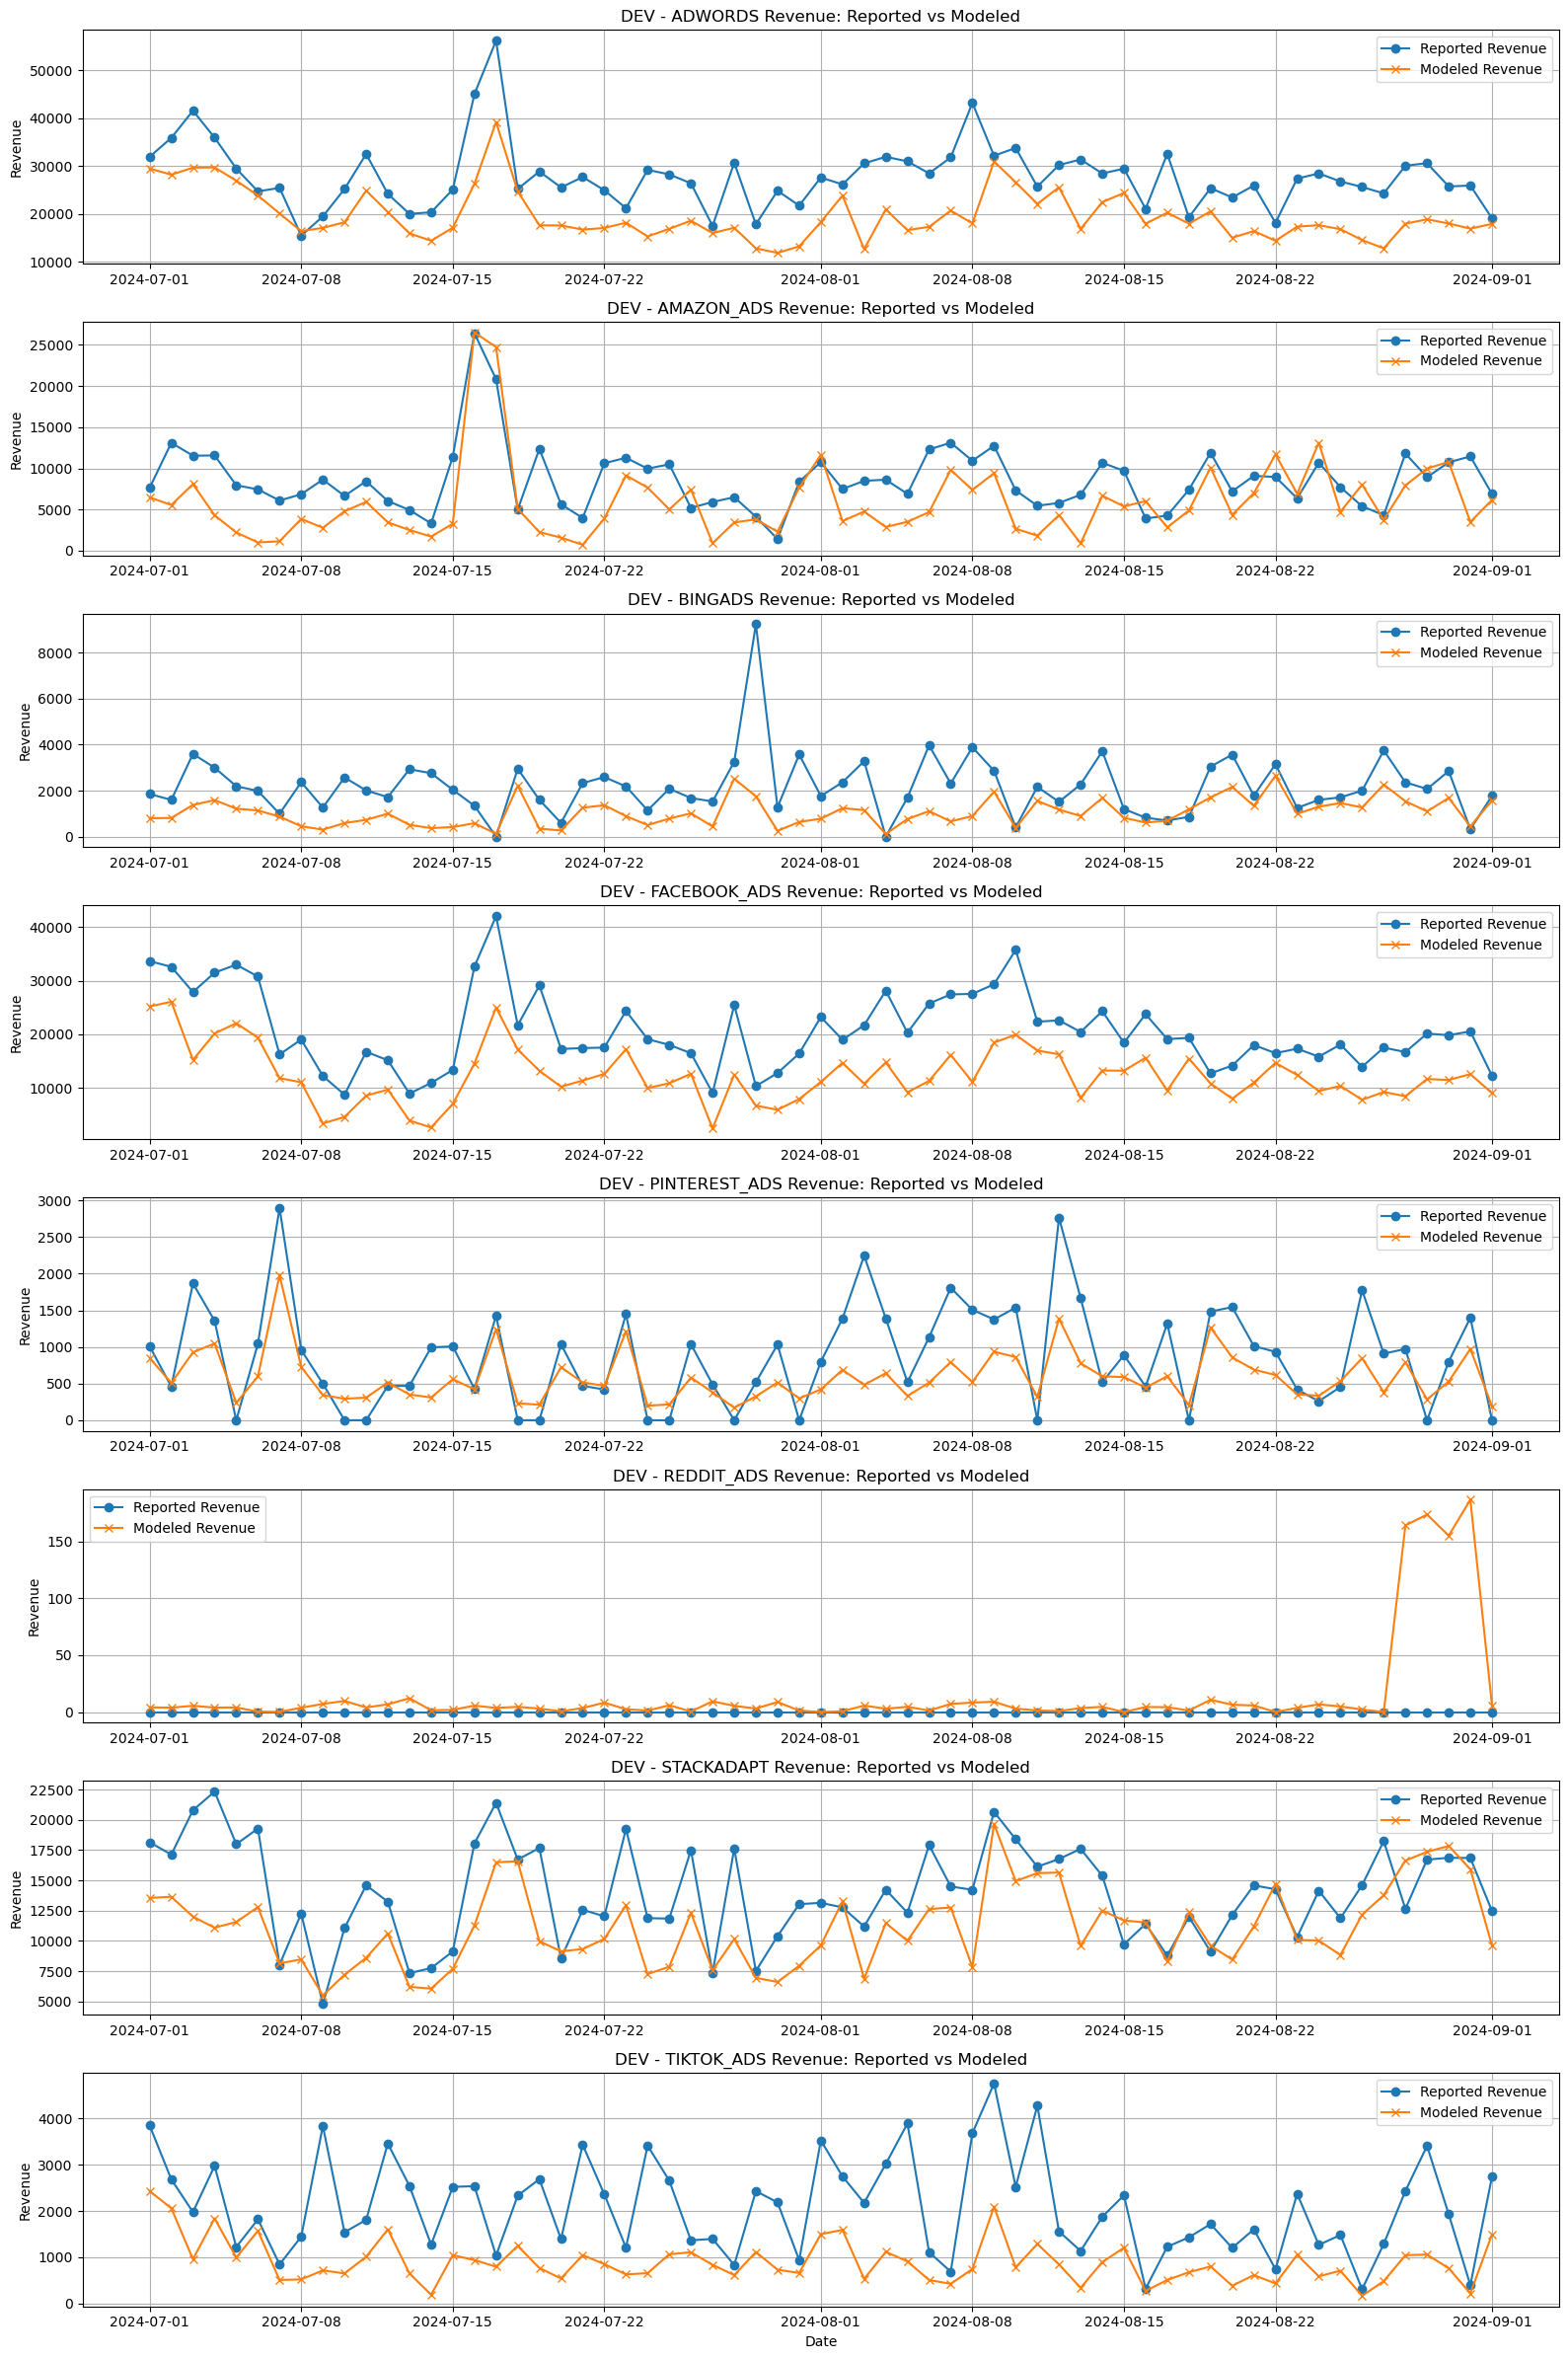

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\42854344.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comparison.groupby(["REPORTED_DATE","MARKETING_CHANNEL"])


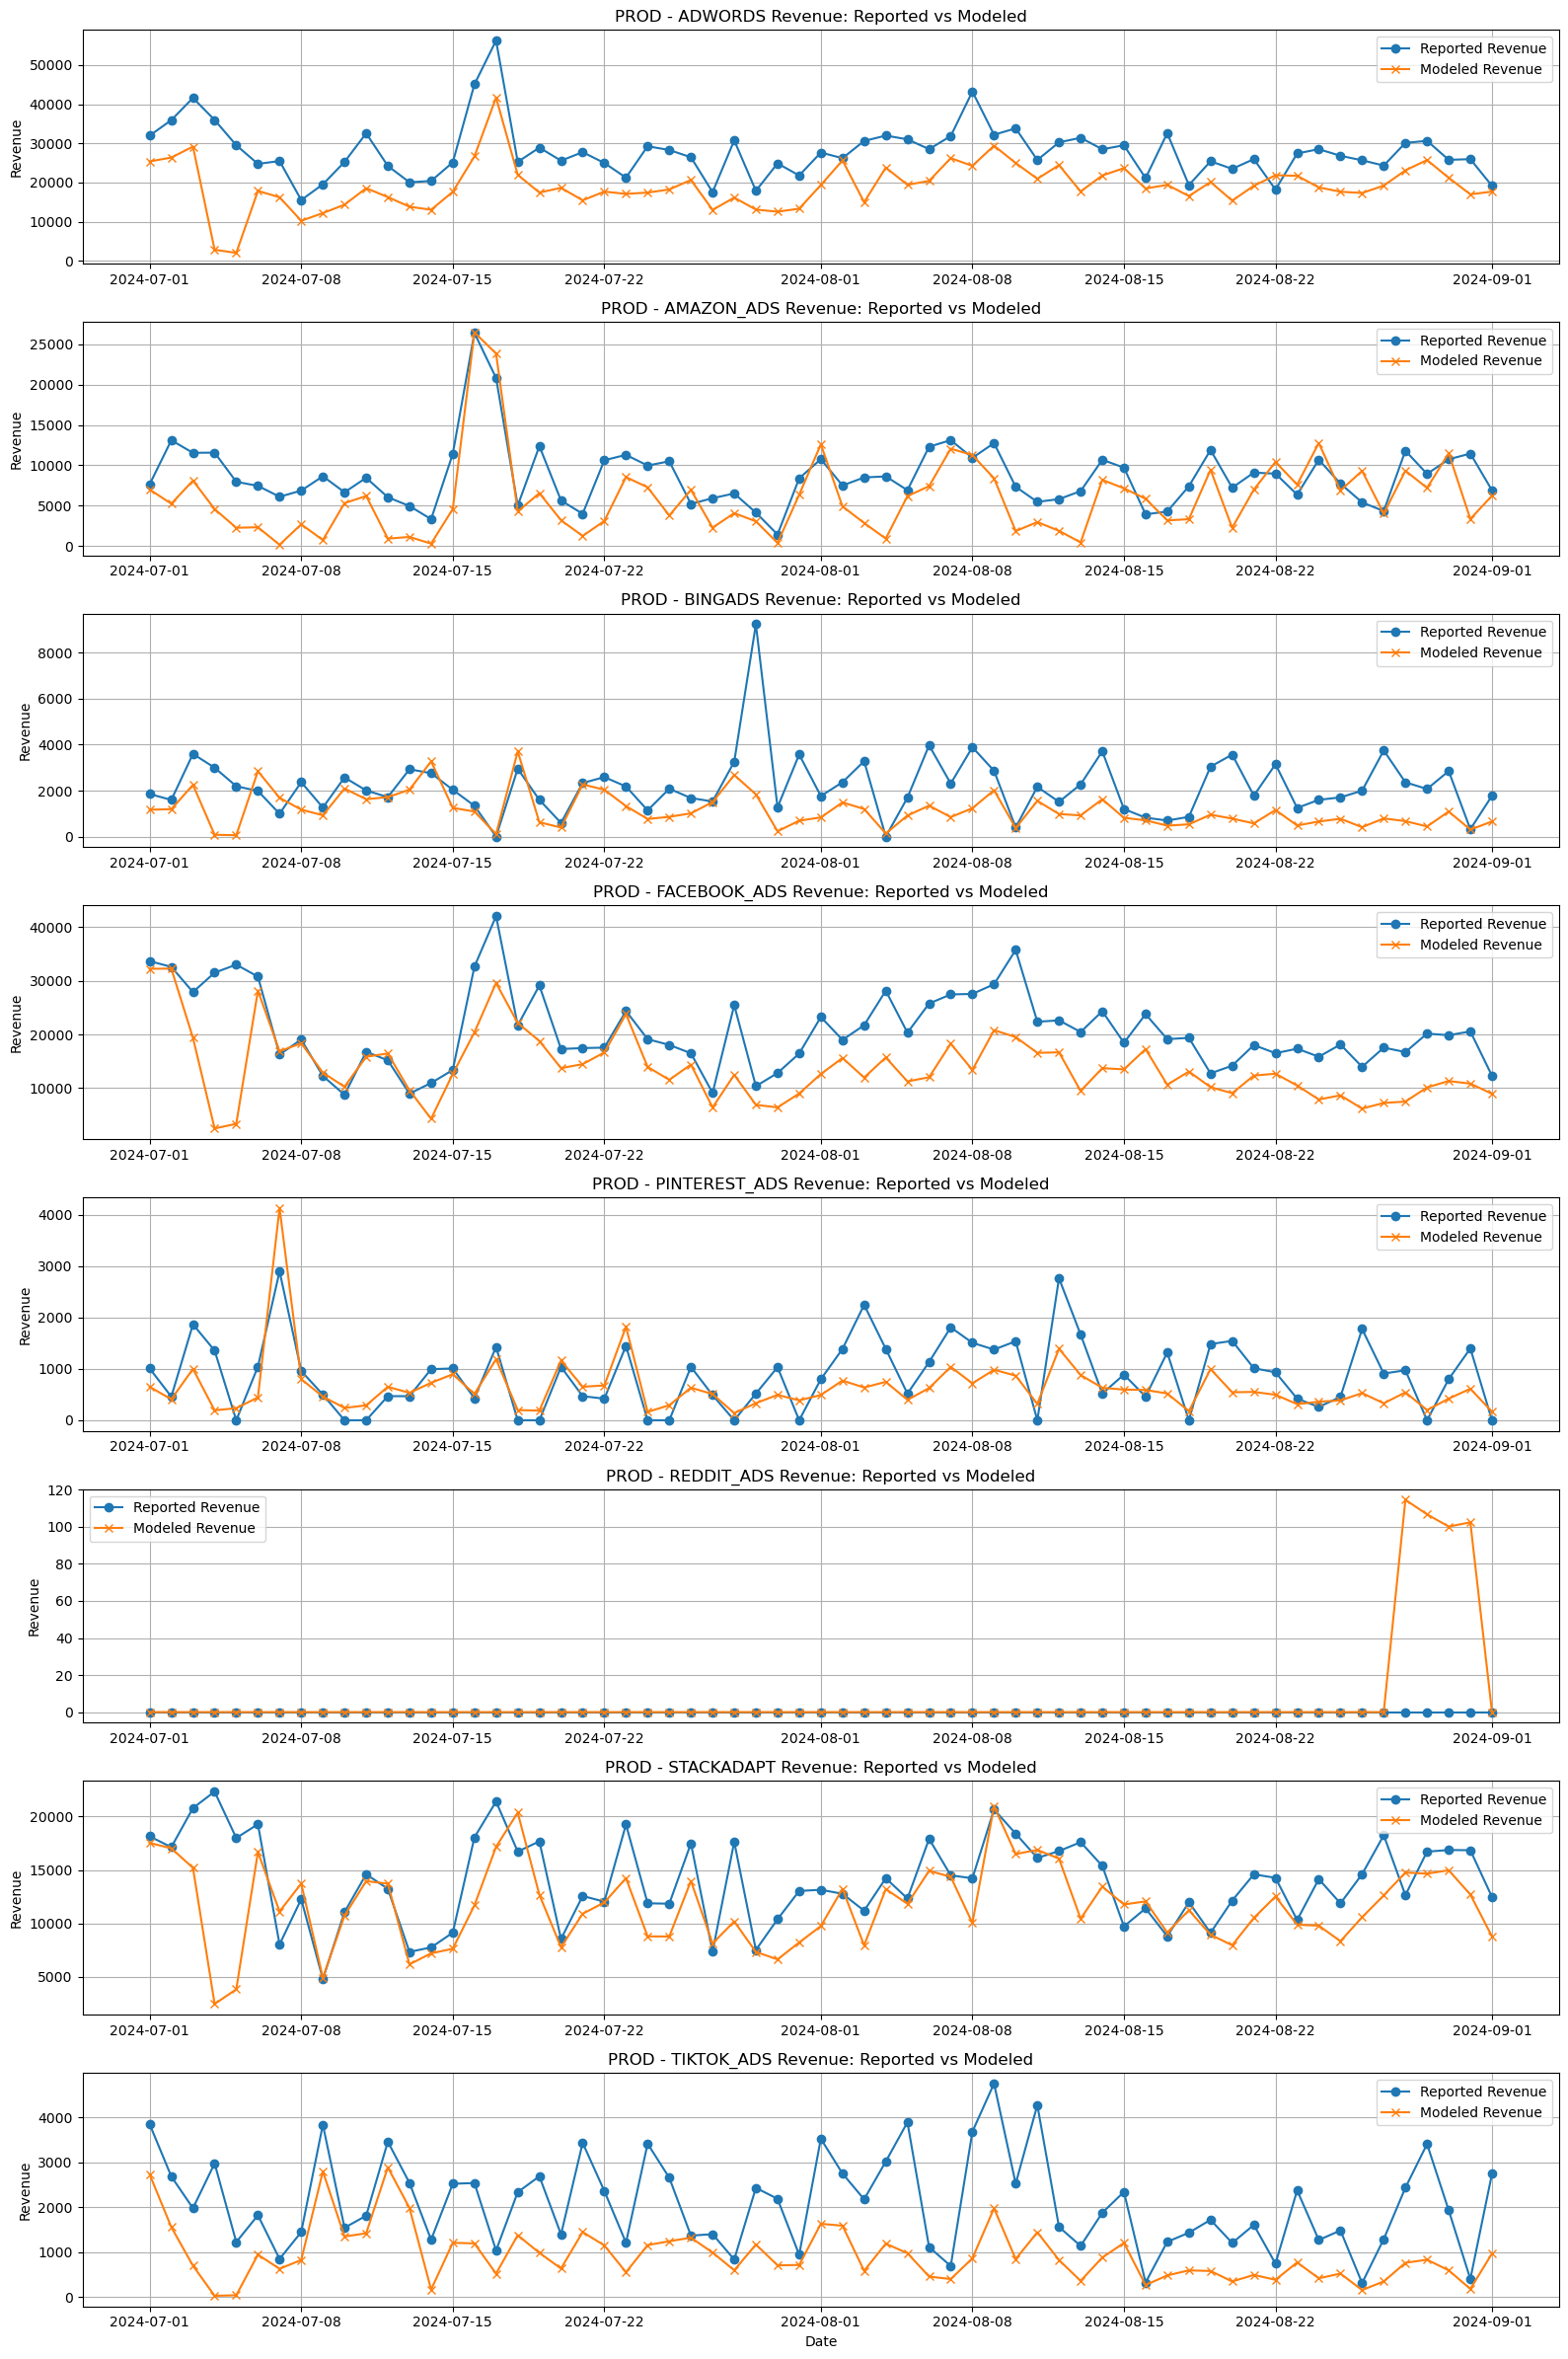

In [75]:
for env in ["dev", "prod"]:
    reported = reported_pivots[f"{env}_reported"]
    modeled = modeled_pivots[f"{env}_modeled"].copy()
    modeled["TOTAL_MODELED_REVENUE"] = modeled.get("FIRST_ORDER_REVENUE", 0) + modeled.get("SECOND_ORDER_REVENUE", 0)

    # Merge per campaign
    comparison = reported.merge(
        modeled[["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID","TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
        how="inner"
    )

    # Fill missing reported revenue
    comparison["CHANNEL_REPORTED_REVENUE"] = comparison.get("CHANNEL_REPORTED_REVENUE", 0)

    # Aggregate by channel + date
    rev_by_channel = (
        comparison.groupby(["REPORTED_DATE","MARKETING_CHANNEL"])
        [["CHANNEL_REPORTED_REVENUE","TOTAL_MODELED_REVENUE"]]
        .sum()
        .reset_index()
    )

    # Plot time series per channel
    channels = rev_by_channel["MARKETING_CHANNEL"].unique()
    n_channels = len(channels)
    plt.figure(figsize=(16, 3 * n_channels))

    for i, ch in enumerate(channels, 1):
        df_ch = rev_by_channel[rev_by_channel["MARKETING_CHANNEL"]==ch].sort_values("REPORTED_DATE")
        plt.subplot(n_channels, 1, i)
        plt.plot(df_ch["REPORTED_DATE"], df_ch["CHANNEL_REPORTED_REVENUE"], marker='o', label="Reported Revenue")
        plt.plot(df_ch["REPORTED_DATE"], df_ch["TOTAL_MODELED_REVENUE"], marker='x', label="Modeled Revenue")
        plt.title(f"{env.upper()} - {ch} Revenue: Reported vs Modeled")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(True)

    plt.xlabel("Date")
    plt.tight_layout()
    plt.show()


DEV Revenue Comparison Visualizations:


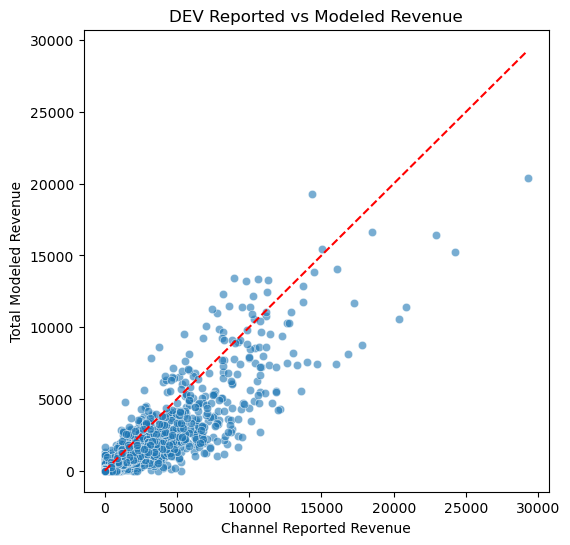

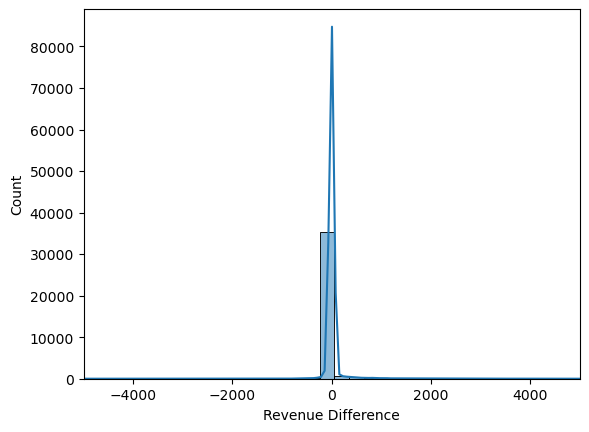

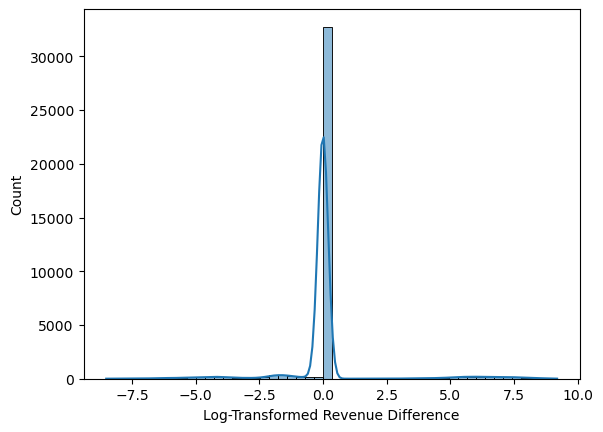

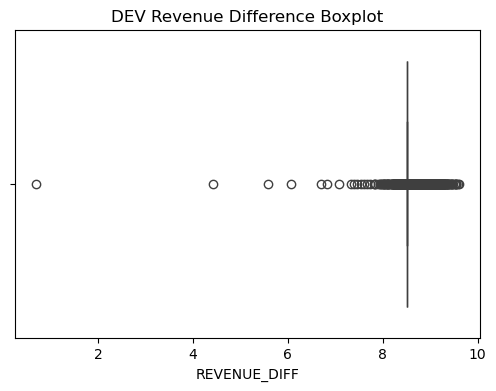

METRIC_NAME,CAMPAIGN_ID,MARKETING_CHANNEL,CHANNEL_REPORTED_REVENUE,TOTAL_MODELED_REVENUE,REVENUE_DIFF
22531,20322881938,ADWORDS,20381.846057,10591.002797,9790.843259
9505,16878784202,ADWORDS,20836.495600,11412.299522,9424.196078
8915,20322881938,ADWORDS,24258.556056,15209.378278,9049.177778
27859,20322881938,ADWORDS,17781.971707,8747.086154,9034.885552
9507,20322881938,ADWORDS,29260.358537,20403.118809,8857.239728
9749,6540409655777,FACEBOOK_ADS,16860.580000,8138.953659,8721.626341
32003,20322881938,ADWORDS,15975.474026,7417.238796,8558.235230
21589,6540409655777,FACEBOOK_ADS,10750.790000,2674.341112,8076.448888
34963,20322881938,ADWORDS,13549.529401,5577.658119,7971.871282
22181,6540409655777,FACEBOOK_ADS,12160.940000,4271.477322,7889.462678



PROD Revenue Comparison Visualizations:


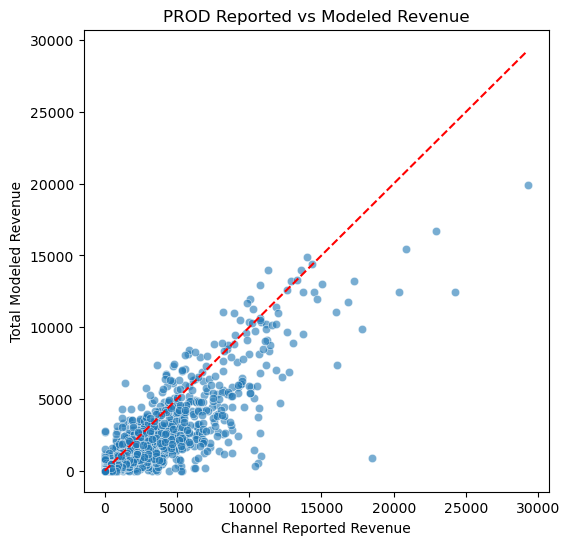

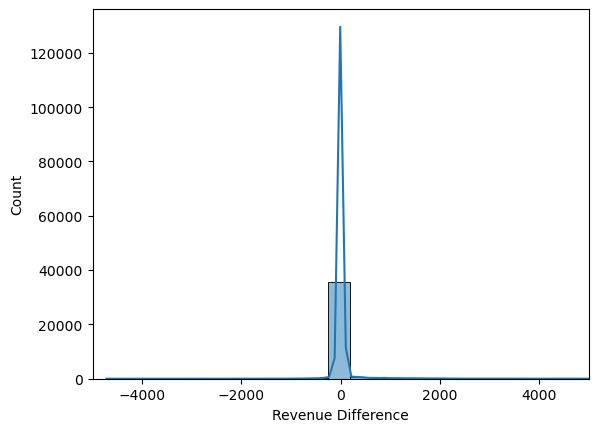

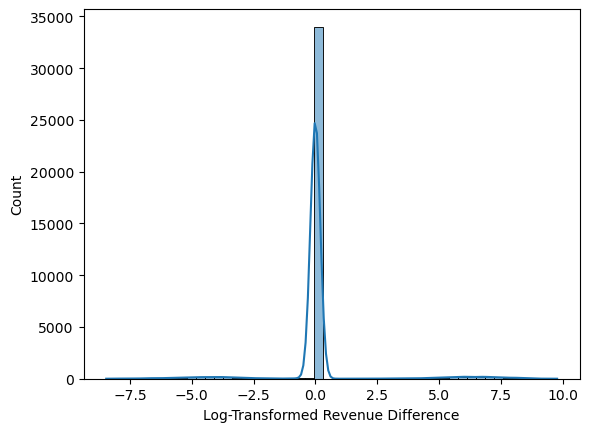

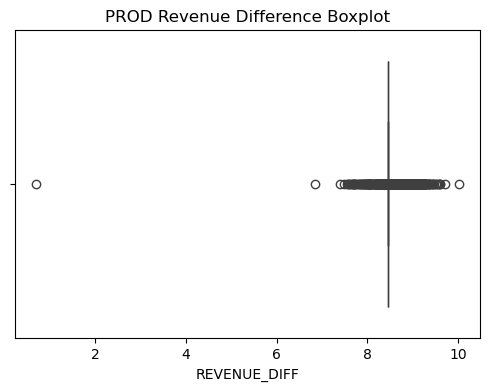

METRIC_NAME,CAMPAIGN_ID,MARKETING_CHANNEL,CHANNEL_REPORTED_REVENUE,TOTAL_MODELED_REVENUE,REVENUE_DIFF
1811,20322881938,ADWORDS,18527.162957,908.223246,17618.939711
8915,20322881938,ADWORDS,24258.556056,12438.872508,11819.683548
2403,20322881938,ADWORDS,10631.067623,535.599268,10095.468355
2645,6540409655777,FACEBOOK_ADS,10370.700000,346.601190,10024.098810
2049,6320155260377,FACEBOOK_ADS,10835.740000,994.937586,9840.802414
9507,20322881938,ADWORDS,29260.358537,19909.592794,9350.765743
2641,6320155260377,FACEBOOK_ADS,10341.810000,1451.301591,8890.508409
5955,20322881938,ADWORDS,16077.499261,7351.756244,8725.743017
21589,6540409655777,FACEBOOK_ADS,10750.790000,2643.790658,8106.999342
22531,20322881938,ADWORDS,20381.846057,12425.409032,7956.437025


In [76]:
for name, df in modeled_pivots.items():
    df["TOTAL_MODELED_REVENUE"] = df.get("FIRST_ORDER_REVENUE", 0) + df.get("SECOND_ORDER_REVENUE", 0)

for env in ["dev", "prod"]:
    comparison = reported_pivots[f"{env}_reported"].merge(
        modeled_pivots[f"{env}_modeled"].copy()[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
        how="inner"
    )
    comparison["REVENUE_DIFF"] = comparison.get("CHANNEL_REPORTED_REVENUE", 0) - comparison["TOTAL_MODELED_REVENUE"]
    
    print(f"\n{env.upper()} Revenue Comparison Visualizations:")

    # 1️⃣ Scatter plot: Reported vs Modeled
    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        x="CHANNEL_REPORTED_REVENUE", y="TOTAL_MODELED_REVENUE", 
        data=comparison, alpha=0.6
    )
    plt.plot([0, comparison["CHANNEL_REPORTED_REVENUE"].max()], 
             [0, comparison["CHANNEL_REPORTED_REVENUE"].max()], 
             color="red", linestyle="--")  # 45-degree line
    plt.title(f"{env.upper()} Reported vs Modeled Revenue")
    plt.xlabel("Channel Reported Revenue")
    plt.ylabel("Total Modeled Revenue")
    plt.show()

    sns.histplot(
        comparison["REVENUE_DIFF"], 
        bins=50, 
        kde=True
    )
    plt.xlim(-5000, 5000)  # adjust based on your data
    plt.xlabel("Revenue Difference")
    plt.show()

    # Add a small constant to handle zeros/negatives if necessary
    comparison["REVENUE_DIFF_LOG"] = np.sign(comparison["REVENUE_DIFF"]) * np.log1p(np.abs(comparison["REVENUE_DIFF"]))

    sns.histplot(comparison["REVENUE_DIFF_LOG"], bins=50, kde=True)
    plt.xlabel("Log-Transformed Revenue Difference")
    plt.show()

    # 3️⃣ Boxplot for quick summary
    plt.figure(figsize=(6,4))
    shift = abs(comparison["REVENUE_DIFF"].min()) + 1  # ensures all values > 0
    log_diff = np.log1p(comparison["REVENUE_DIFF"] + shift)
    sns.boxplot(x=log_diff)
    plt.title(f"{env.upper()} Revenue Difference Boxplot")
    plt.show()

    # 4️⃣ Top 10 campaigns with largest absolute differences
    top_outliers = comparison.nlargest(10, "REVENUE_DIFF")
    display(top_outliers[["CAMPAIGN_ID", "MARKETING_CHANNEL", "CHANNEL_REPORTED_REVENUE", "TOTAL_MODELED_REVENUE", "REVENUE_DIFF"]])

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4005761577.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  reported_pivot = dev_reported.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4005761577.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  modeled_pivot = dev_modeled.pivot_table(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4005761577.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for channel, group in merged_df.groupby("MARKETING_CHAN

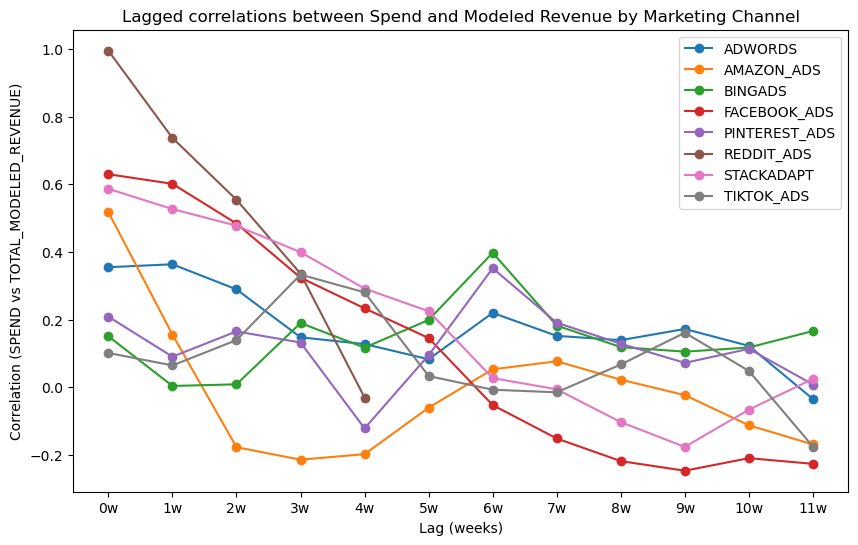

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4005761577.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_df = merged_df.groupby("MARKETING_CHANNEL").agg({
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\4005761577.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_df.sort_values("ROI", ascending=False), x="MARKETING_CHANNEL", y="ROI", palette="viridis")


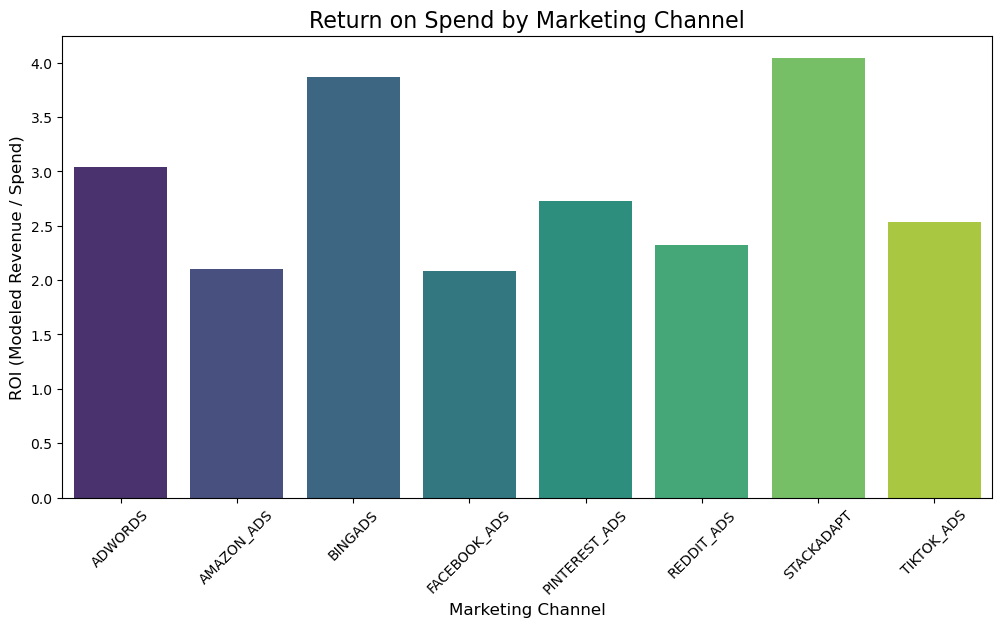

In [82]:

# ---- 1️⃣ Pivot the reported dataset ----
reported_pivot = dev_reported.pivot_table(
    index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    columns="METRIC_NAME",
    values="METRIC_VALUE",
    aggfunc="sum"  # sum in case multiple rows per day/campaign
).reset_index()

# ---- 2️⃣ Pivot the modeled dataset ----
modeled_pivot = dev_modeled.pivot_table(
    index=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    columns="METRIC_NAME",
    values="METRIC_VALUE",
    aggfunc="sum"
).reset_index()

# ---- 3️⃣ Compute total modeled revenue ----
modeled_pivot["TOTAL_MODELED_REVENUE"] = (
    modeled_pivot.get("FIRST_ORDER_REVENUE", 0) +
    modeled_pivot.get("SECOND_ORDER_REVENUE", 0)
)

# ---- 4️⃣ Merge reported spend with modeled revenue ----
merged_df = reported_pivot.merge(
    modeled_pivot[["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID", "TOTAL_MODELED_REVENUE"]],
    on=["REPORTED_DATE", "MARKETING_CHANNEL", "CAMPAIGN_ID"],
    how="inner"
)

# ---- 5️⃣ Compute lagged correlations by MARKETING_CHANNEL ----
# Choose max lag in weeks
max_lag_weeks = 12
merged_df = merged_df.sort_values(["MARKETING_CHANNEL", "REPORTED_DATE"])

lag_corrs = {}


for channel, group in merged_df.groupby("MARKETING_CHANNEL"):
    group = group.set_index("REPORTED_DATE")
    
    # keep only numeric columns
    numeric_cols = group.select_dtypes(include=np.number).columns
    group_numeric = group[numeric_cols].resample("D").sum().fillna(0)
    
    corrs = []
    for lag in range(max_lag_weeks):
        cor = group_numeric["SPEND"].shift(lag).corr(group_numeric["TOTAL_MODELED_REVENUE"])
        corrs.append(cor)
    
    lag_corrs[channel] = corrs

# ---- 6️⃣ Plot lagged correlations ----
plt.figure(figsize=(10,6))
for channel, corrs in lag_corrs.items():
    plt.plot(range(len(corrs)), corrs, marker='o', label=channel)
plt.xticks(range(0, max_lag_weeks), labels=[f"{i}w" for i in range(0, max_lag_weeks)])
plt.xlabel("Lag (weeks)")
plt.ylabel("Correlation (SPEND vs TOTAL_MODELED_REVENUE)")
plt.title("Lagged correlations between Spend and Modeled Revenue by Marketing Channel")
plt.legend()
plt.show()

# ---- 2️⃣ Bar chart of return on spend (ROI) ----
# Compute ROI: total modeled revenue / total spend per channel
roi_df = merged_df.groupby("MARKETING_CHANNEL").agg({
    "TOTAL_MODELED_REVENUE": "sum",
    "SPEND": "sum"
}).reset_index()
roi_df["ROI"] = roi_df["TOTAL_MODELED_REVENUE"] / roi_df["SPEND"]

plt.figure(figsize=(12, 6))
sns.barplot(data=roi_df.sort_values("ROI", ascending=False), x="MARKETING_CHANNEL", y="ROI", palette="viridis")
plt.title("Return on Spend by Marketing Channel", fontsize=16)
plt.xlabel("Marketing Channel", fontsize=12)
plt.ylabel("ROI (Modeled Revenue / Spend)", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# low to high for bar graph

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1224314250.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi = merged_df.groupby("MARKETING_CHANNEL").apply(
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1224314250.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  roi = merged_df.groupby("MARKETING_CHANNEL").apply(


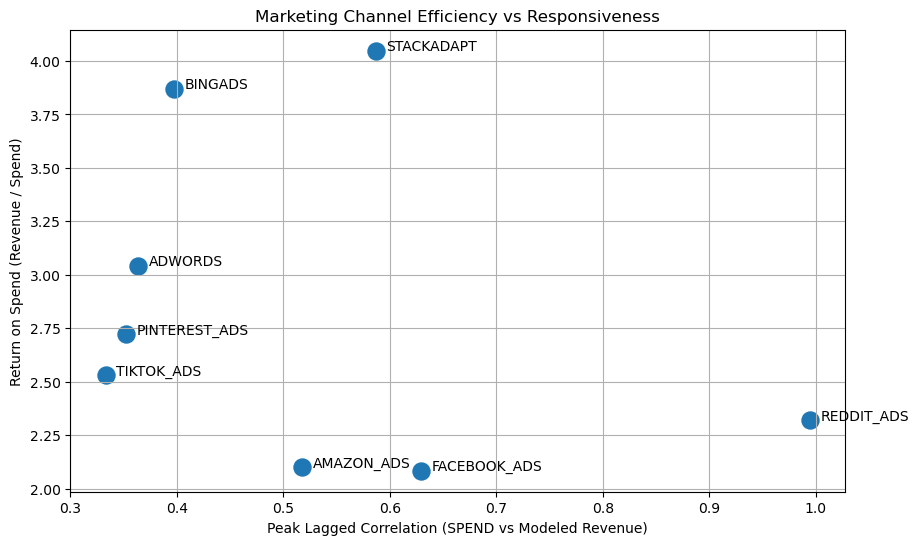

In [78]:
# Compute peak lag correlation per channel
peak_corrs = {channel: max([c for c in corrs if c is not None]) for channel, corrs in lag_corrs.items()}

# Compute ROI per channel
roi = merged_df.groupby("MARKETING_CHANNEL").apply(
    lambda x: x["TOTAL_MODELED_REVENUE"].sum() / x["SPEND"].sum()
)

# Combine into DataFrame
roi_corr_df = pd.DataFrame({
    "CHANNEL": peak_corrs.keys(),
    "PEAK_LAG_CORR": peak_corrs.values(),
    "ROI": roi.values
})

# Plot
plt.figure(figsize=(10,6))
plt.scatter(roi_corr_df["PEAK_LAG_CORR"], roi_corr_df["ROI"], s=150)

for i, row in roi_corr_df.iterrows():
    plt.text(row["PEAK_LAG_CORR"] + 0.01, row["ROI"], row["CHANNEL"], fontsize=10)

plt.xlabel("Peak Lagged Correlation (SPEND vs Modeled Revenue)")
plt.ylabel("Return on Spend (Revenue / Spend)")
plt.title("Marketing Channel Efficiency vs Responsiveness")
plt.grid(True)
plt.show()

In [79]:
ENV = "dev"   # or "prod"
reported = dev_reported if ENV == "dev" else prod_reported
modeled  = dev_modeled  if ENV == "dev" else prod_modeled

# Ensure REPORTED_DATE is datetime
for df in [reported, modeled]:
    if not np.issubdtype(df["REPORTED_DATE"].dtype, np.datetime64):
        df["REPORTED_DATE"] = pd.to_datetime(df["REPORTED_DATE"])

# =========================
# 1) Pivot to wide metrics
# =========================
# Reported: need SPEND (and optionally CHANNEL_REPORTED_REVENUE if you want to compare later)
rep_wide = (
    reported
    .pivot_table(index=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
                 columns="METRIC_NAME",
                 values="METRIC_VALUE",
                 aggfunc="sum")
    .reset_index()
)

# Modeled: need FIRST_ORDER_REVENUE + SECOND_ORDER_REVENUE
mod_wide = (
    modeled
    .pivot_table(index=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
                 columns="METRIC_NAME",
                 values="METRIC_VALUE",
                 aggfunc="sum")
    .reset_index()
)

# Total modeled revenue
for col in ["FIRST_ORDER_REVENUE","SECOND_ORDER_REVENUE"]:
    if col not in mod_wide.columns:
        mod_wide[col] = 0.0
mod_wide["TOTAL_MODELED_REVENUE"] = mod_wide["FIRST_ORDER_REVENUE"] + mod_wide["SECOND_ORDER_REVENUE"]

# =========================
# 2) Merge spend with modeled revenue (by date, channel, campaign)
# =========================
merged = (
    rep_wide[["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID","SPEND"]]
    .merge(
        mod_wide[["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID","TOTAL_MODELED_REVENUE"]],
        on=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
        how="inner"
    )
)

# =========================
# 3) Aggregate to weekly by channel (sum over campaigns)
#    -> pick your week anchor; here we use week starting Monday
# =========================
merged["WEEK"] = merged["REPORTED_DATE"].dt.to_period("W-MON").dt.start_time
weekly = (
    merged.groupby(["WEEK","MARKETING_CHANNEL"], as_index=False)[["SPEND","TOTAL_MODELED_REVENUE"]]
    .sum()
    .sort_values(["MARKETING_CHANNEL","WEEK"])
)

# =========================
# 4) MARGINAL ROI (week-over-week deltas within channel)
# =========================
def winsorize(s, lower=0.01, upper=0.99):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

mroi_rows = []
for ch, g in weekly.groupby("MARKETING_CHANNEL"):
    g = g.sort_values("WEEK").copy()
    g["DELTA_SPEND"] = g["SPEND"].diff()
    g["DELTA_REV"]   = g["TOTAL_MODELED_REVENUE"].diff()
    # Keep only positive spend increases to approximate marginal effect
    mask = g["DELTA_SPEND"] > 0
    g["MROI"] = np.where(mask, g["DELTA_REV"] / g["DELTA_SPEND"], np.nan)
    # Winsorize per channel to stabilize
    if g["MROI"].notna().sum() > 5:
        g.loc[g["MROI"].notna(), "MROI"] = winsorize(g["MROI"].dropna())
    mroi_rows.append(g)

mroi_df = pd.concat(mroi_rows, ignore_index=True)

# Channel summary: marginal ROI stats + total ROI
mroi_summary = (
    mroi_df.groupby("MARKETING_CHANNEL")
    .agg(
        weeks_observed=("MROI", lambda s: s.notna().sum()),
        mroi_mean=("MROI","mean"),
        mroi_median=("MROI","median"),
        mroi_p75=("MROI", lambda s: s.quantile(0.75)),
        total_spend=("SPEND","sum"),
        total_revenue=("TOTAL_MODELED_REVENUE","sum")
    )
    .reset_index()
)
mroi_summary["total_roi"] = mroi_summary["total_revenue"] / mroi_summary["total_spend"].replace(0, np.nan)

print(f"\n[{ENV.upper()}] Marginal ROI summary (per channel):")
print(mroi_summary.sort_values("mroi_median", ascending=False))

# =========================
# 5) DECOMPOSITION via multi-channel ridge OLS with non-negativity
#    y_t = alpha + Σ_k beta_k * Spend_{k,t-lag}
# =========================
# (a) Build weekly channel x week matrix of spend (X) and total modeled revenue target (y)
lag_weeks = 0   # set to 1 to use previous week's spend
# Pivot spends to channels
X = weekly.pivot(index="WEEK", columns="MARKETING_CHANNEL", values="SPEND").fillna(0).sort_index()
# Weekly total modeled revenue across channels (sum over channels each week)
y = weekly.groupby("WEEK")["TOTAL_MODELED_REVENUE"].sum().reindex(X.index).fillna(0)

X = X.shift(lag_weeks).fillna(0)

# (b) Ridge-regularized non-negative OLS
# Solve: min ||y - Xb - a||^2 + λ||b||^2, with b >= 0
lam = 1e-2
# Augment X for ridge: stack sqrt(lam)*I
XtX = X.T @ X + lam * np.eye(X.shape[1])
Xty = X.T @ y

# Initial ridge solution
beta = np.linalg.solve(XtX, Xty)

# Enforce non-negativity by simple iterative clipping/refit (garrote-style)
active = beta > 0
# If XtX is a DataFrame, convert it:
XtX = XtX.to_numpy()
Xty = Xty.to_numpy()


for _ in range(3):  # a few passes
    if active.sum() == 0:
        break
    XtX_a = XtX[np.ix_(active, active)]
    Xty_a = Xty[active]
    beta_a = np.linalg.solve(XtX_a, Xty_a)
    active = beta > 0

# Intercept
alpha = float(y.mean() - X.values.mean(axis=0) @ beta)

# (c) Contributions per channel & over time
contrib = X.multiply(beta, axis=1)  # each column k: beta_k * spend_k_t
contrib["INTERCEPT"] = alpha  # constant baseline per week

# If intercept is negative, set to 0 and re-scale positives to match total y (optional guard)
if contrib["INTERCEPT"].mean() < 0:
    contrib["INTERCEPT"] = 0.0

# Scale contributions so rows sum ~ y (avoid small misspecifications)
row_sum = contrib.sum(axis=1).replace(0, np.nan)
scale = (y / row_sum).fillna(0)
contrib_scaled = contrib.mul(scale, axis=0)

# Channel-level totals
channel_contrib = contrib_scaled.drop(columns=["INTERCEPT"]).sum()
channel_share = (channel_contrib / channel_contrib.sum()).sort_values(ascending=False).rename("share")

decomposition_summary = pd.DataFrame({
    "beta": pd.Series(beta, index=X.columns),
    "contribution_total": channel_contrib.reindex(X.columns).fillna(0),
    "contribution_share": channel_share.reindex(X.columns).fillna(0)
}).sort_values("contribution_total", ascending=False)

print(f"\n[{ENV.upper()}] Decomposition (ridge OLS, non-negative, lag={lag_weeks} weeks):")
print(decomposition_summary.head(20))

# =========================
# 6) Handy join: combine decomposition with ROI summary
# =========================
final_channel_table = (
    mroi_summary.set_index("MARKETING_CHANNEL")
    .join(decomposition_summary[["beta","contribution_total","contribution_share"]], how="left")
    .sort_values("contribution_total", ascending=False)
    .reset_index()
)

print(f"\n[{ENV.upper()}] Channel scorecard (decomposition + ROI):")
print(final_channel_table)

C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1123055773.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1123055773.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index=["REPORTED_DATE","MARKETING_CHANNEL","CAMPAIGN_ID"],
C:\Users\danny\AppData\Local\Temp\ipykernel_22844\1123055773.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warni


[DEV] Marginal ROI summary (per channel):
  MARKETING_CHANNEL  weeks_observed  mroi_mean  mroi_median  mroi_p75  \
2           BINGADS               5   2.548413     4.965762  7.174960   
4     PINTEREST_ADS               4 -12.835540     3.363360  4.957267   
3      FACEBOOK_ADS               5  -1.491236     1.705206  1.714057   
5        REDDIT_ADS               1   1.637199     1.637199  1.637199   
6        STACKADAPT               7  75.762163     1.106483  4.897486   
7        TIKTOK_ADS               4   0.655167     0.272024  1.196184   
1        AMAZON_ADS               6   1.427481     0.239551  2.954582   
0           ADWORDS               4   0.384461     0.168969  3.148378   

     total_spend  total_revenue  total_roi  
2   17106.550000   6.619284e+04   3.869444  
4   13599.547515   3.704106e+04   2.723698  
3  371944.950000   7.750426e+05   2.083756  
5     400.000000   9.277016e+02   2.319254  
6  172529.547402   6.983656e+05   4.047803  
7   22302.560000   5.645875e+

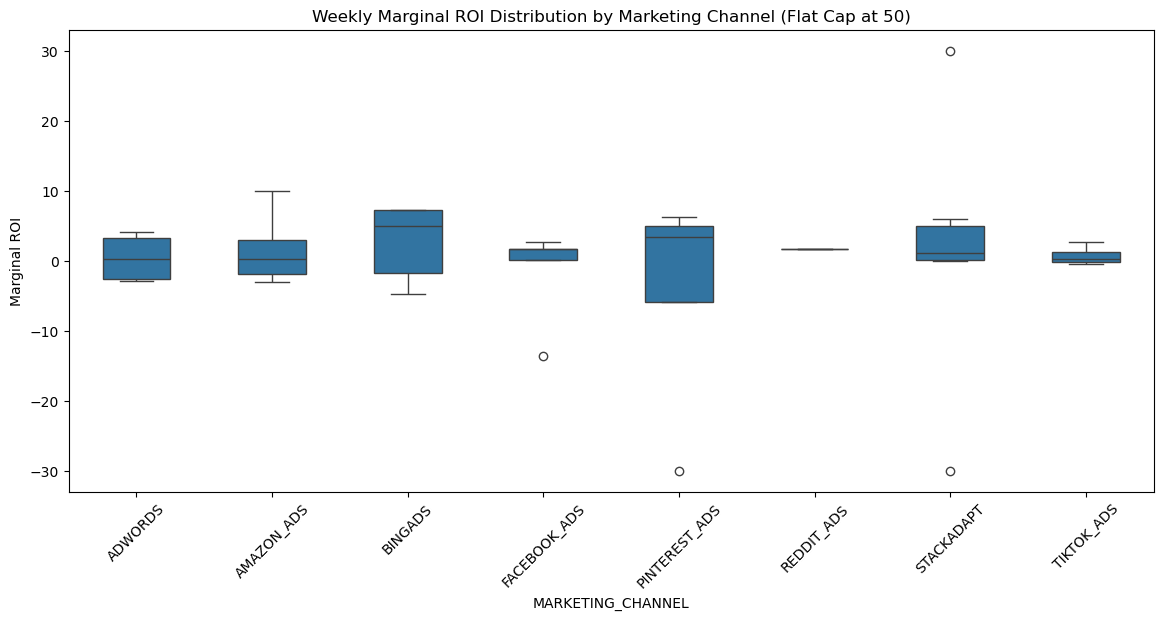

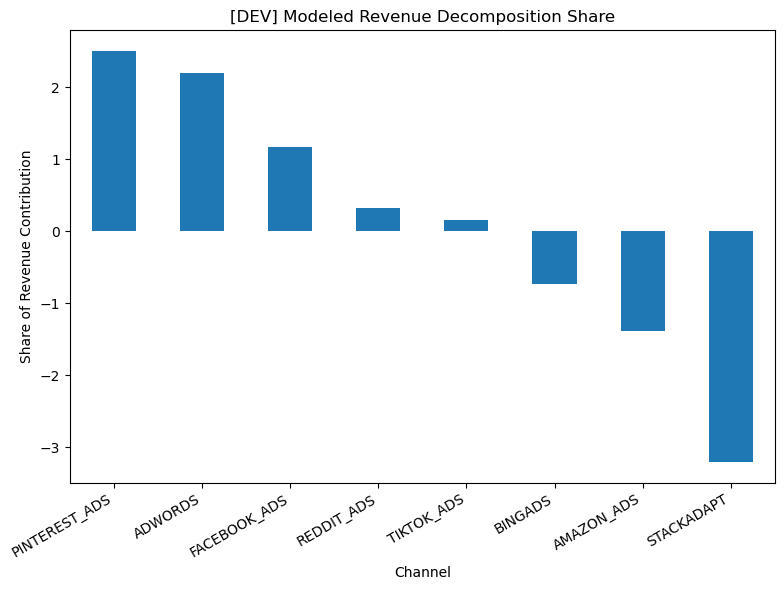

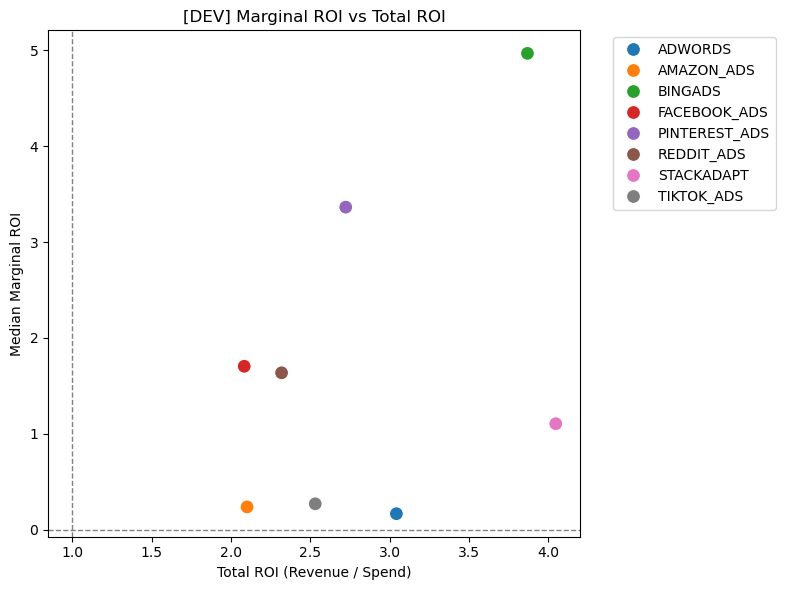

In [80]:
# Flat cap MROI at 50
mroi_df_capped = mroi_df.copy()
mroi_df_capped["MROI"] = mroi_df_capped["MROI"].clip(upper=30, lower = -30)

plt.figure(figsize=(14,6))
sns.boxplot(
    data=mroi_df_capped,
    x="MARKETING_CHANNEL",
    y="MROI",
    width=0.5  # visually wide boxes
)
plt.title("Weekly Marginal ROI Distribution by Marketing Channel (Flat Cap at 50)")
plt.ylabel("Marginal ROI")
plt.xticks(rotation=45)
plt.show()

# Bar chart of contribution share
plt.figure(figsize=(8,6))
decomposition_summary["contribution_share"].plot(kind="bar")
plt.title(f"[{ENV.upper()}] Modeled Revenue Decomposition Share")
plt.ylabel("Share of Revenue Contribution")
plt.xlabel("Channel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Scatter plot of total ROI vs median marginal ROI
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=final_channel_table,
    x="total_roi",
    y="mroi_median",
    hue="MARKETING_CHANNEL",
    s=100
)
plt.axhline(0, color="gray", linestyle="--", lw=1)
plt.axvline(1, color="gray", linestyle="--", lw=1)
plt.title(f"[{ENV.upper()}] Marginal ROI vs Total ROI")
plt.xlabel("Total ROI (Revenue / Spend)")
plt.ylabel("Median Marginal ROI")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# instead of box plot, is there a way to look at a percentage of volatility for each marketing channel

# 

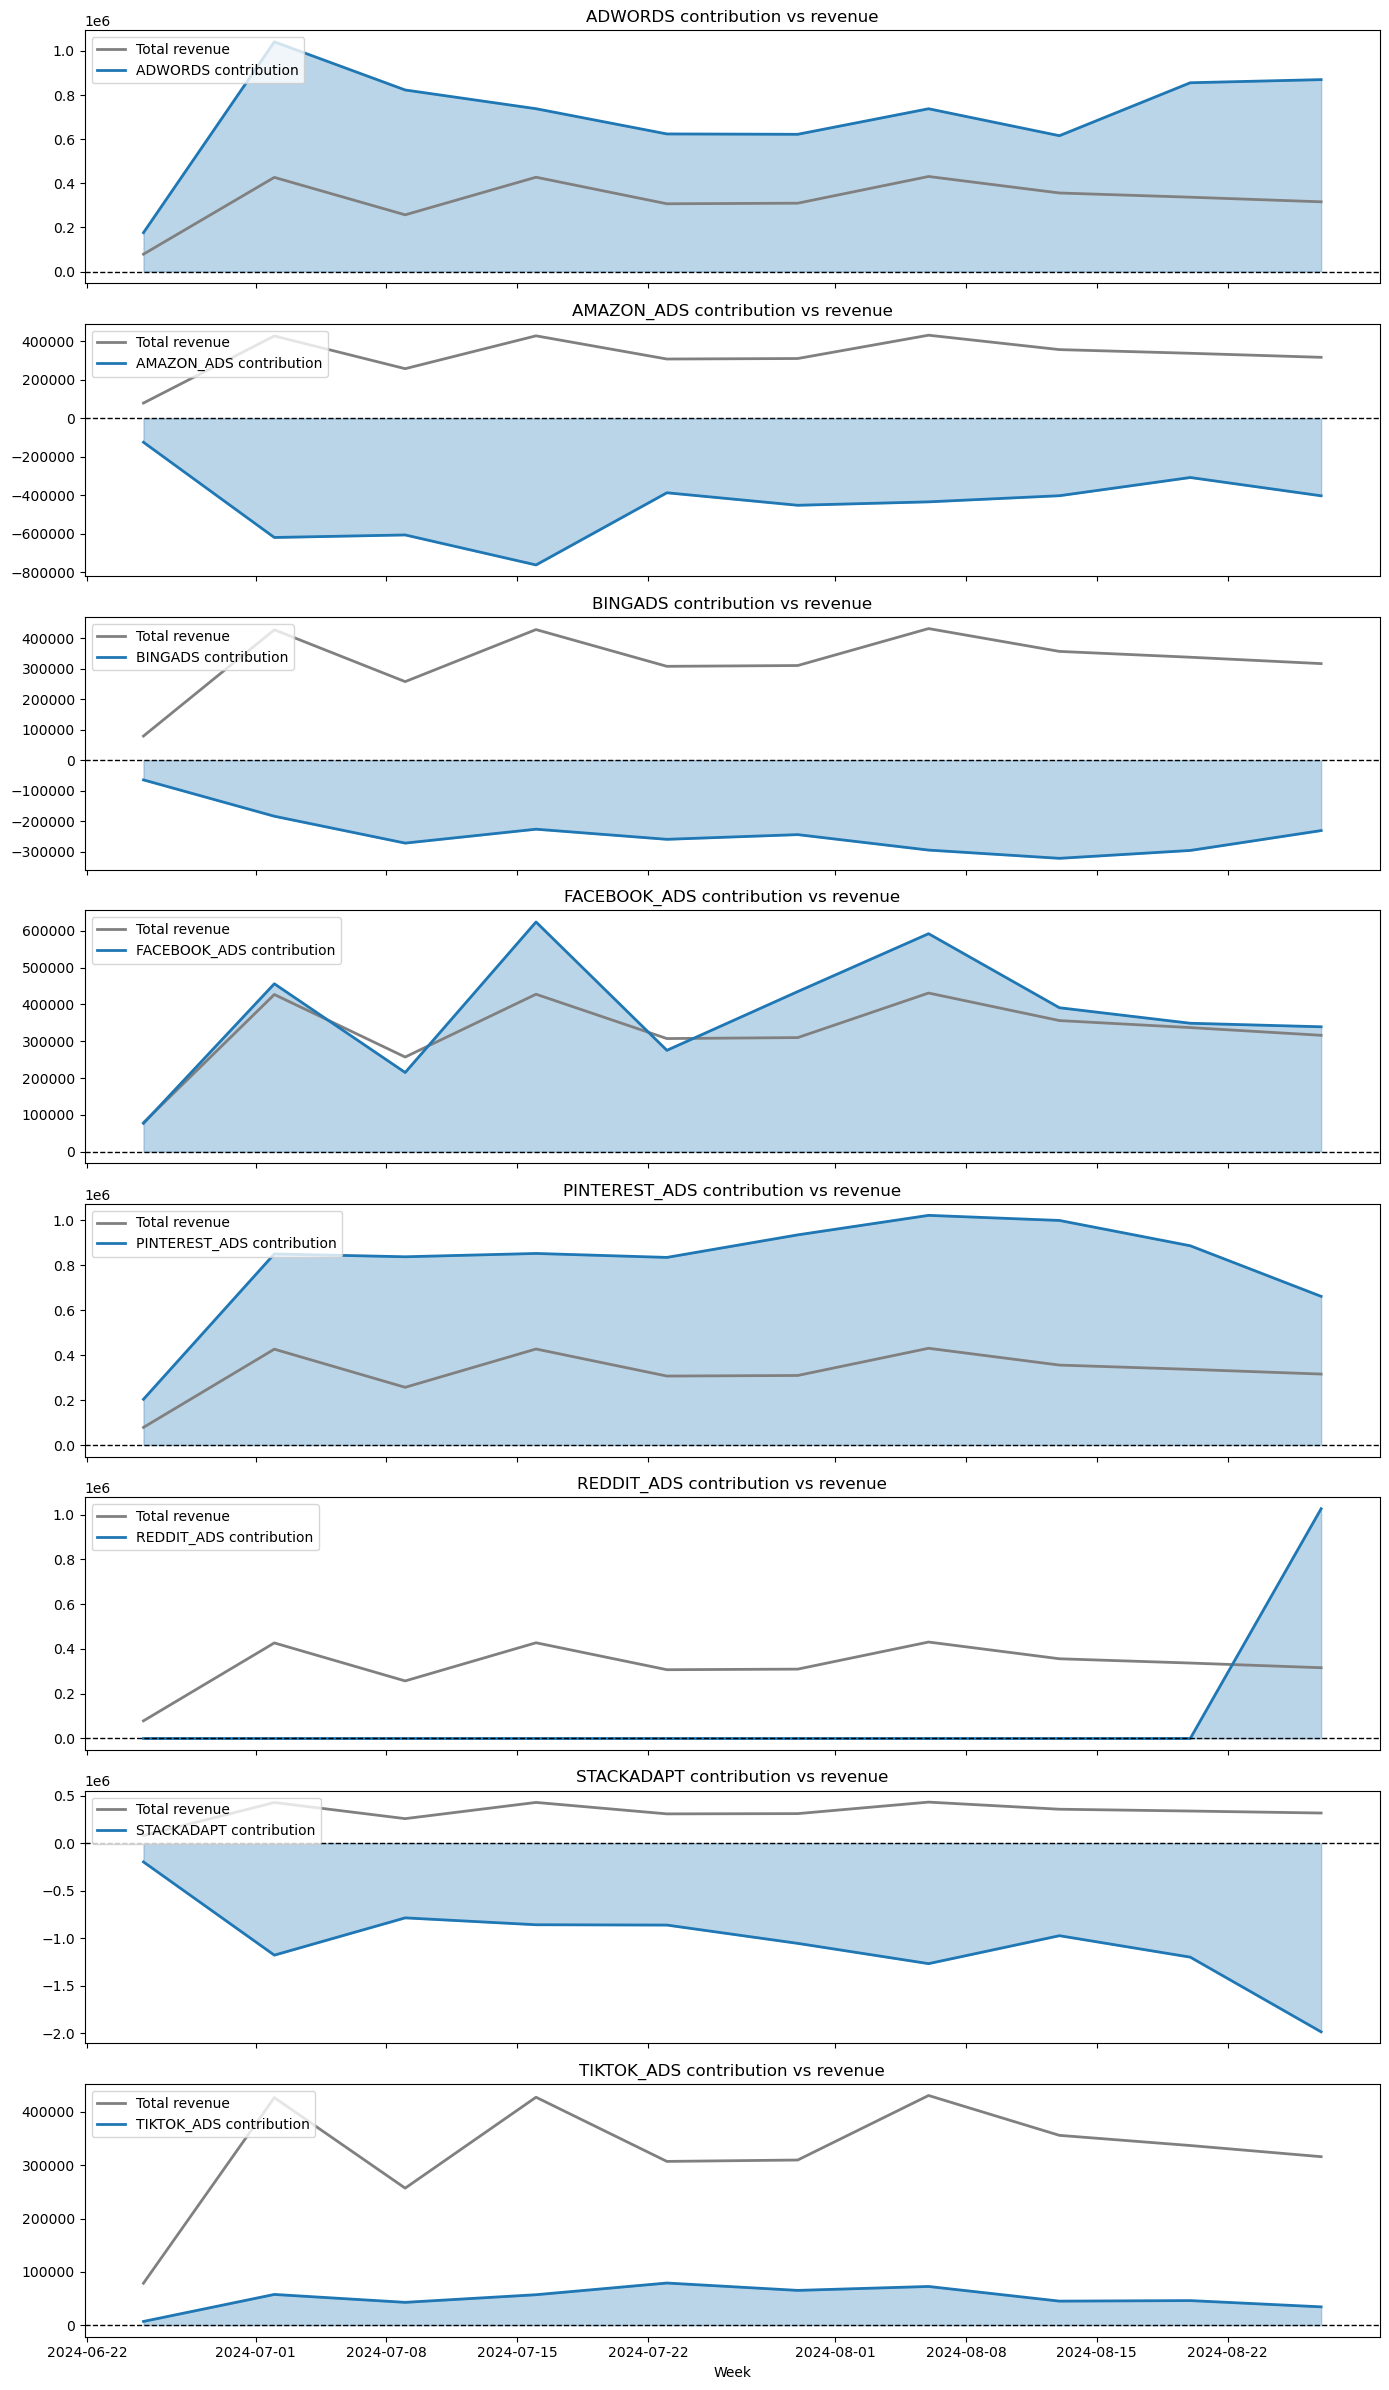

In [81]:
channels = [c for c in contrib_scaled.columns if c != "INTERCEPT"]

fig, axes = plt.subplots(len(channels), 1, figsize=(14, 3*len(channels)), sharex=True)

for i, ch in enumerate(channels):
    ax = axes[i]

    # total revenue (gray line)
    ax.plot(y.index, y.values, color="gray", lw=2, label="Total revenue")

    # channel contribution (blue area + line)
    ax.fill_between(y.index, contrib_scaled[ch], alpha=0.3, color="C0")
    ax.plot(y.index, contrib_scaled[ch], lw=2, color="C0", label=f"{ch} contribution")

    ax.axhline(0, color="black", linestyle="--", lw=1)
    ax.set_title(f"{ch} contribution vs revenue", fontsize=12)
    ax.legend(loc="upper left")

plt.xlabel("Week")
plt.tight_layout()
plt.show()

* No missing values, no negative metric values
* StackAdapt ROI seems to be driven by two outliers
- high total ROI, but negative revenue contribution share in the decomposition: could be highly correlated with other channels' spend
- best return on spend: could be driven by the two outliers
- total ROI compared to median marginal ROI much higher
- incremental effect not as strong as raw ROI implies
* Weekly Marginal ROI vs marketing channel, wide boxes means more volatile dollar per spend
* Using the ridge OLS decomposition has some caveats, in that it provides a linear approximation between spend and modeled revenue, but cannot handle non-linearities, adstock, or channel interactions, only giving a point estimate. It treats each channel as a fixed linear term, and we're only using it for a simple and quick comparison
* Channel Reported Revenue generally significantly higher than Total Modeled Revenue

# create heatmap between each amrketing channel, find which combination leads to optimal ROI

# generally better descriptions for each graph, create a narrative/story